In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
# ============================================================
# CELL 1 — Initialize SLM, camera, FourierSLM
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.meadowlark import Meadowlark


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)


# ------------------------------------------------------------
# SLM
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)



# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("\nWavefront file exists:")
print(WAVEFRONT_PHASE_PATH.exists())

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
Wavefront file exists:
True


In [4]:
# ============================================================
# CELL 2 — Load wavefront correction + post-wavefront Fourier calibration
# ============================================================

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)

slm.source["phase"] = wavefront_phase


print("Wavefront correction installed:")
print("phase" in slm.source)

print("\nslm.phase_correct:")
print(slm.phase_correct)


Wavefront correction installed:
True

slm.phase_correct:
True


In [8]:
# ============================================================
# MANUAL PATCH TEST
# Watch camera separately in Vimba X Viewer
#
# Change only:
#   PATCH_DIAMETER_MM
#   CORRECTION_ON
# and rerun this cell.
# ============================================================

import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# USER CONTROLS
# ------------------------------------------------------------

PATCH_DIAMETER_MM = 0.66      # e.g. 1.0, 3.0, 5.0, 7.0, 9.5
CORRECTION_ON = True         # False = OFF, True = ON

CARRIER_PERIOD_PX = 16
DUMP_PERIOD_PX = 3
PIXEL_UM = 8.0


# ------------------------------------------------------------
# Load wavefront correction if not already loaded
# ------------------------------------------------------------

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)

# Install correction into slmsuite
slm.source["phase"] = wavefront_phase


# ------------------------------------------------------------
# SLM coordinates
# ------------------------------------------------------------

ny, nx = slm.shape

cx = (nx - 1) / 2
cy = (ny - 1) / 2

yy, xx = np.indices((ny, nx))

x = xx - cx
y = yy - cy


# ------------------------------------------------------------
# Circular diagnostic patch
# ------------------------------------------------------------

patch_radius_px = (
    PATCH_DIAMETER_MM * 1000
    / (2 * PIXEL_UM)
)

patch_mask = (
    x**2 + y**2 <= patch_radius_px**2
)


# ------------------------------------------------------------
# Useful 16-pixel carrier inside patch
# ------------------------------------------------------------

phase_carrier = (
    2 * np.pi * x / CARRIER_PERIOD_PX
)


# ------------------------------------------------------------
# 3-pixel vertical dump outside patch
# ------------------------------------------------------------

phase_dump = (
    2 * np.pi * y / DUMP_PERIOD_PX
)


# ------------------------------------------------------------
# Combine and wrap
# ------------------------------------------------------------

phase_patch = np.where(
    patch_mask,
    phase_carrier,
    phase_dump,
)

phase_patch = np.mod(
    phase_patch,
    2 * np.pi
)


# Write to SLM
slm.set_phase(
    phase_patch,
    phase_correct=CORRECTION_ON,
    settle=True
)

print("===================================")
print("MANUAL PATCH TEST")
print("===================================")
print(f"Patch diameter       : {PATCH_DIAMETER_MM:.1f} mm")
print(f"Patch diameter       : {2*patch_radius_px:.1f} SLM pixels")
print(f"Carrier period       : {CARRIER_PERIOD_PX} px")
print(f"Wavefront correction : {'ON' if CORRECTION_ON else 'OFF'}")
print("===================================")

MANUAL PATCH TEST
Patch diameter       : 0.7 mm
Patch diameter       : 82.5 SLM pixels
Carrier period       : 16 px
Wavefront correction : ON



Found images:
 1.0 mm : 1mm.tiff
 1.5 mm : 1.5mm.tiff
 2.0 mm : 2mm.tiff
 2.5 mm : 2.5mm.tiff
 3.0 mm : 3mm.tiff
 3.5 mm : 3.5mm.tiff
 4.0 mm : 4mm.tiff
 4.5 mm : 4.5mm.tiff
 5.0 mm : 5mm.tiff
 5.5 mm : 5.5mm.tiff
 6.0 mm : 6mm.tiff
 6.5 mm : 6.5mm.tiff
 7.0 mm : 7mm.tiff
 7.5 mm : 7.5mm.tiff
 8.0 mm : 8mm.tiff
 8.5 mm : 8.5mm.tiff
 9.0 mm : 9mm.tiff
 9.5 mm : 9.5mm.tiff
 9.6 mm : 9.6mm.tiff

Analysing 1.0 mm ...

Analysing 1.5 mm ...

Analysing 2.0 mm ...

Analysing 2.5 mm ...

Analysing 3.0 mm ...

Analysing 3.5 mm ...

Analysing 4.0 mm ...

Analysing 4.5 mm ...

Analysing 5.0 mm ...

Analysing 5.5 mm ...

Analysing 6.0 mm ...

Analysing 6.5 mm ...

Analysing 7.0 mm ...

Analysing 7.5 mm ...

Analysing 8.0 mm ...

Analysing 8.5 mm ...

Analysing 9.0 mm ...

Analysing 9.5 mm ...

Analysing 9.6 mm ...

WAVEFRONT-CORRECTED PATCH SCAN RESULTS
 patch_mm  theory_fwhm_um  fwhm_x_um  fwhm_y_um  scale_x  scale_y  scale_eff  ellipticity   R2_x   R2_y  carrier_peak_counts  saturated
   1.0000 

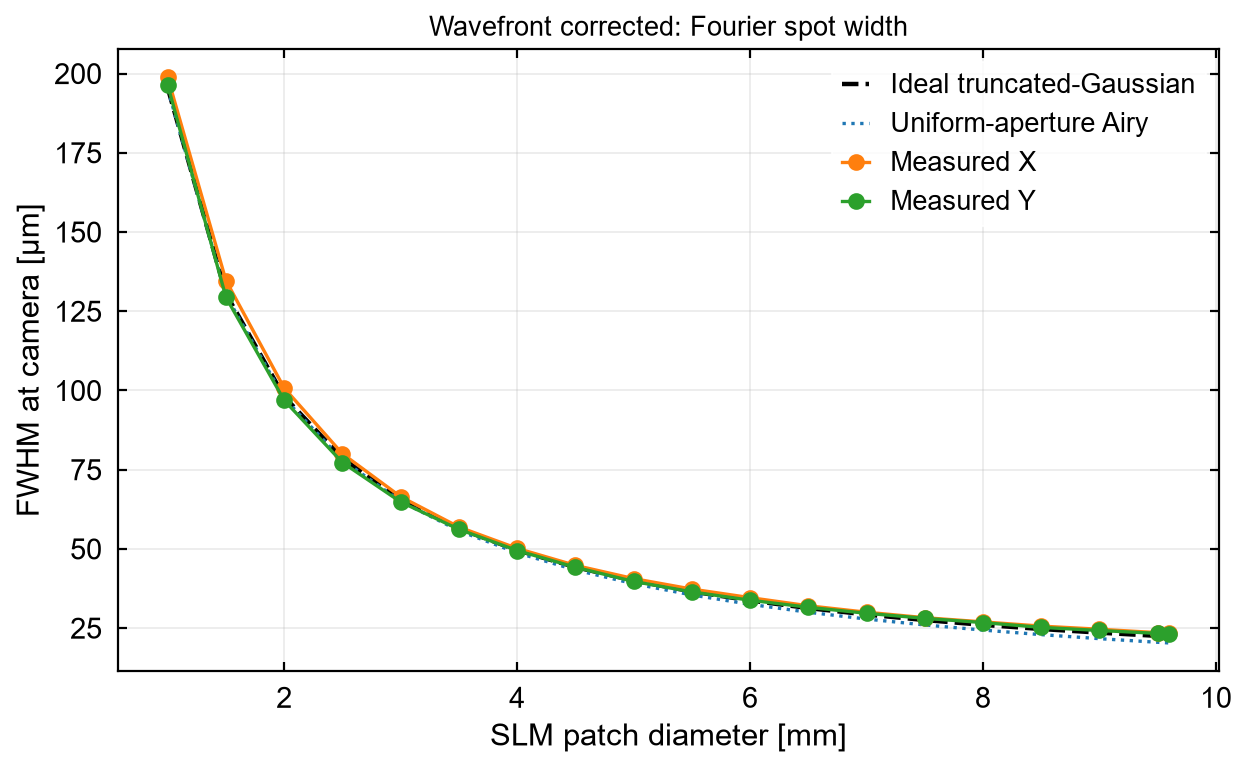

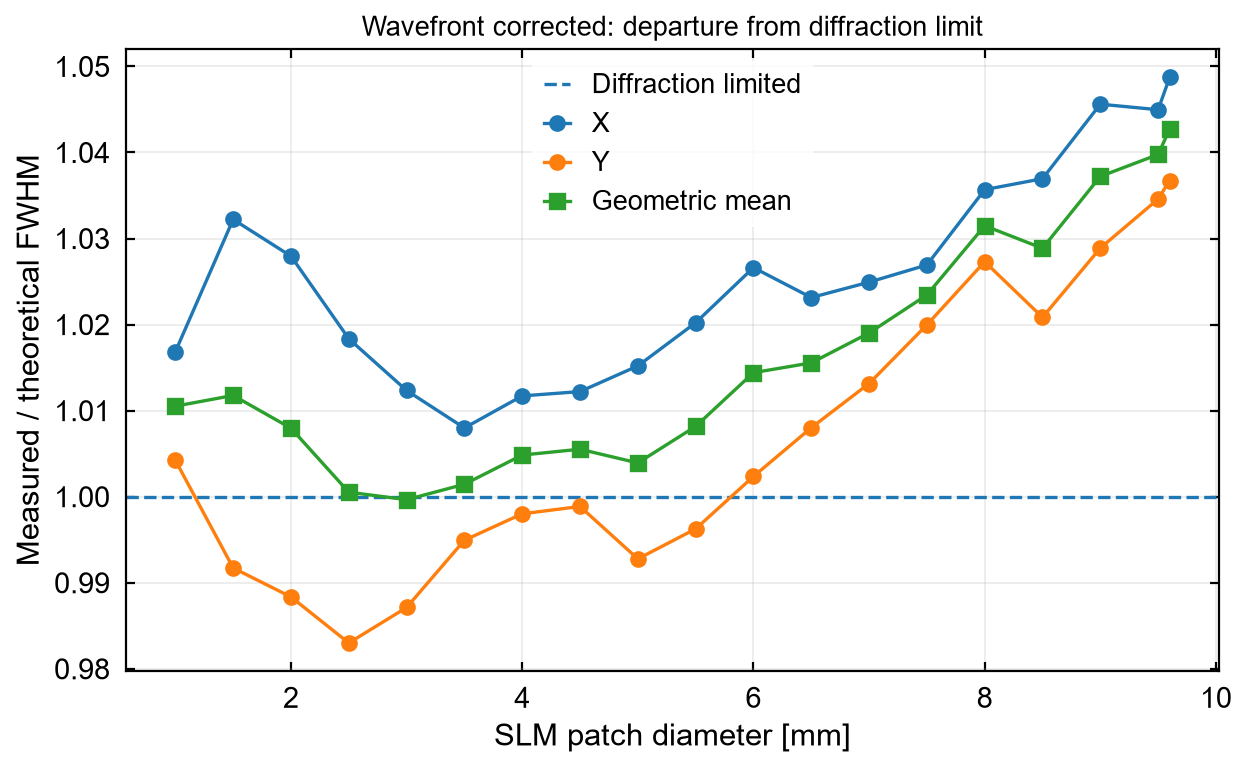

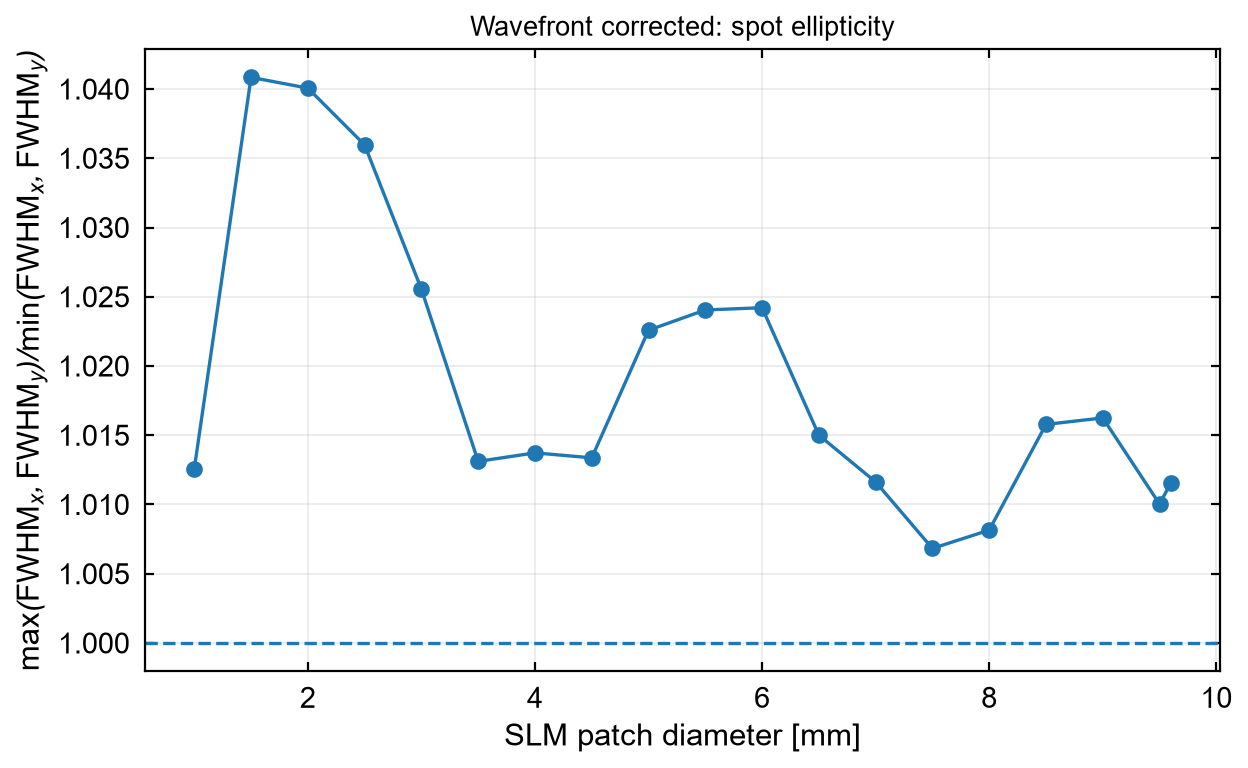

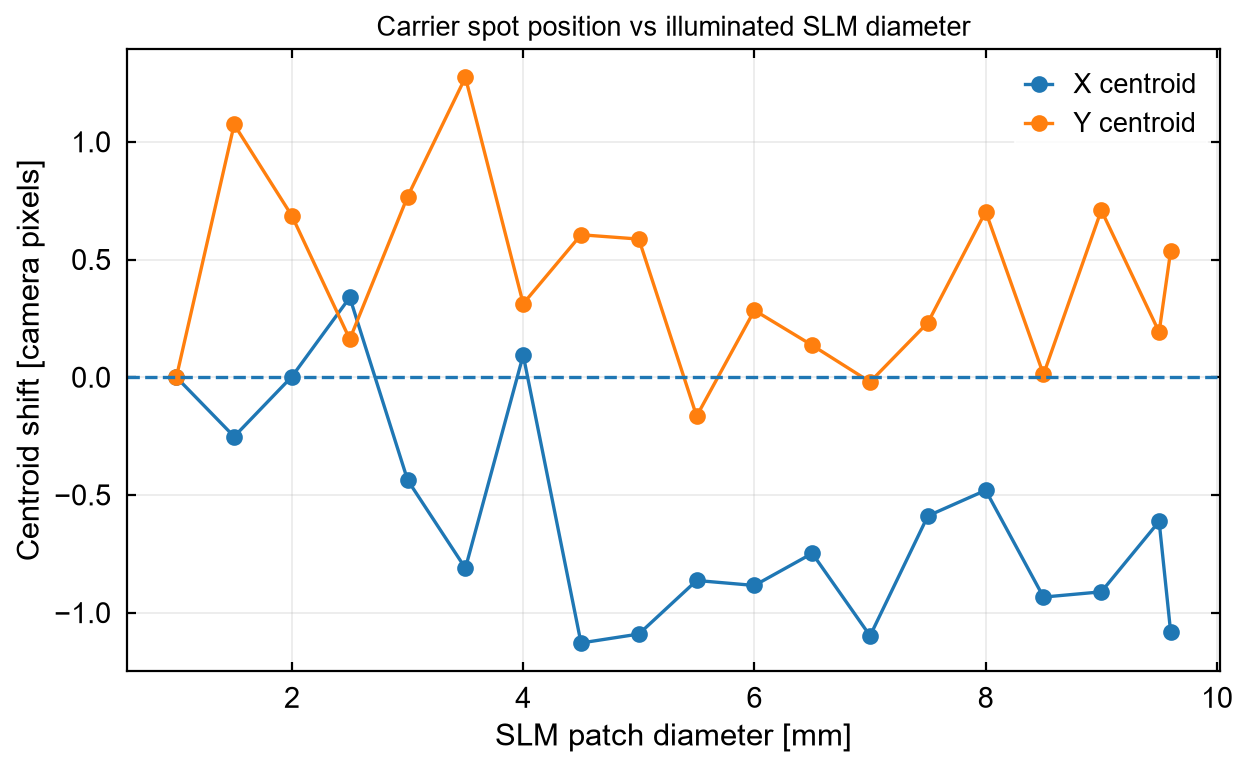

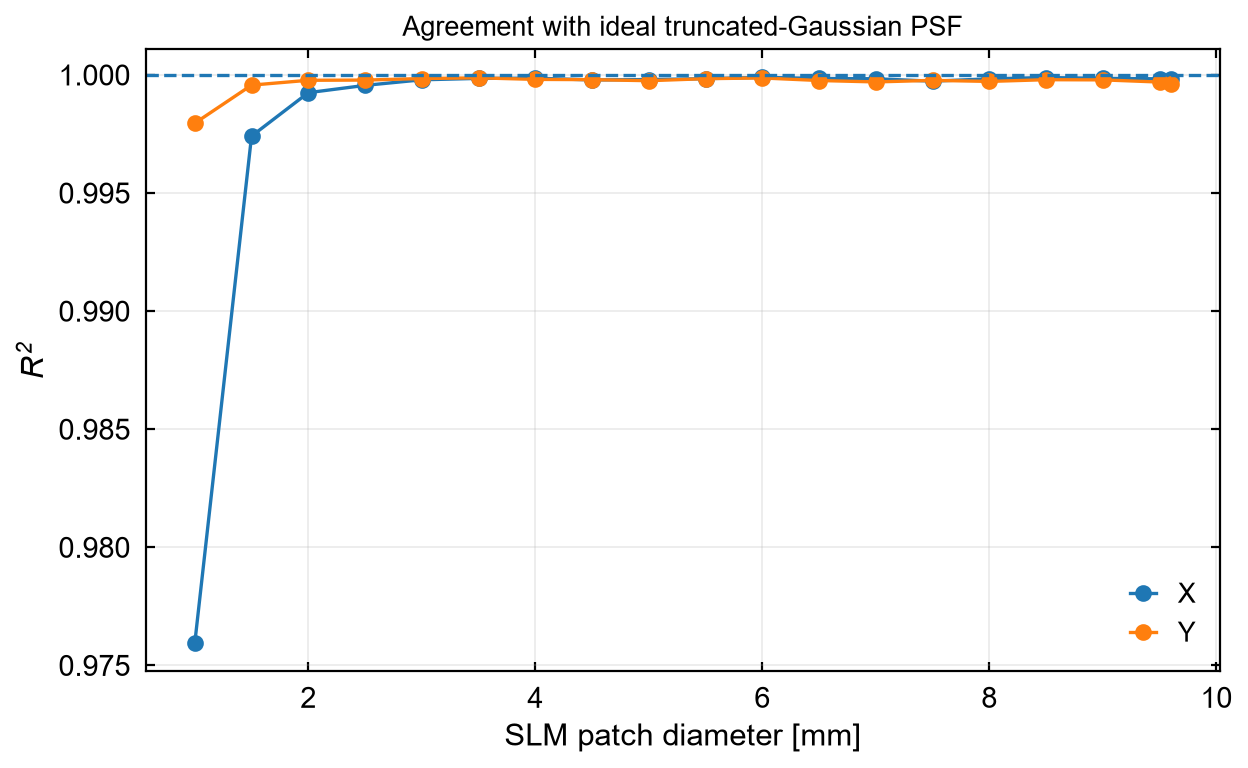

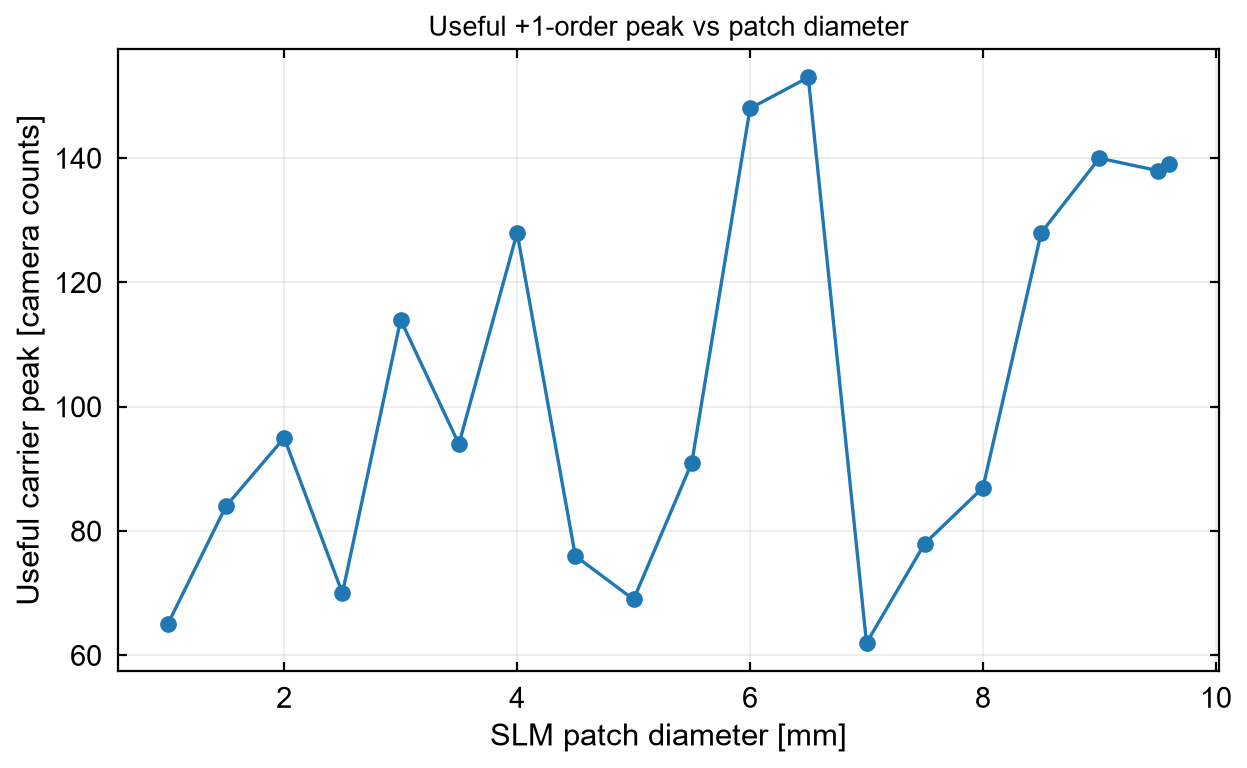


SELECTED FIT EXAMPLES

Plotting 1.0 mm ...


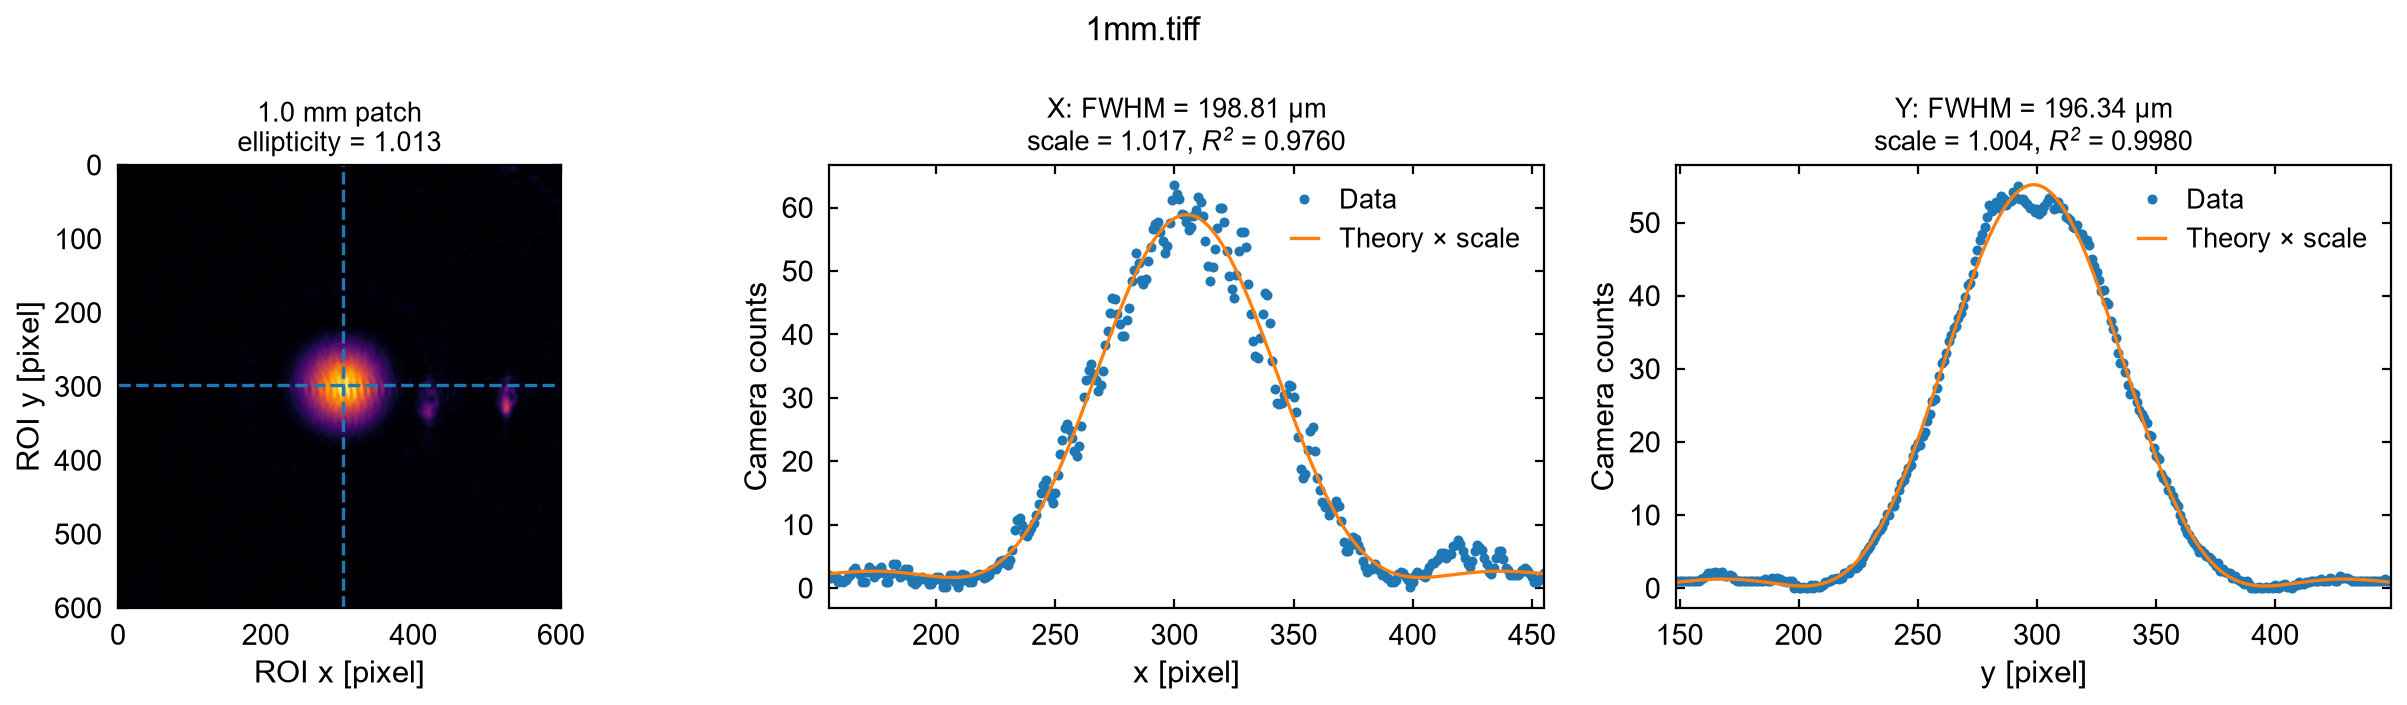


Plotting 3.0 mm ...


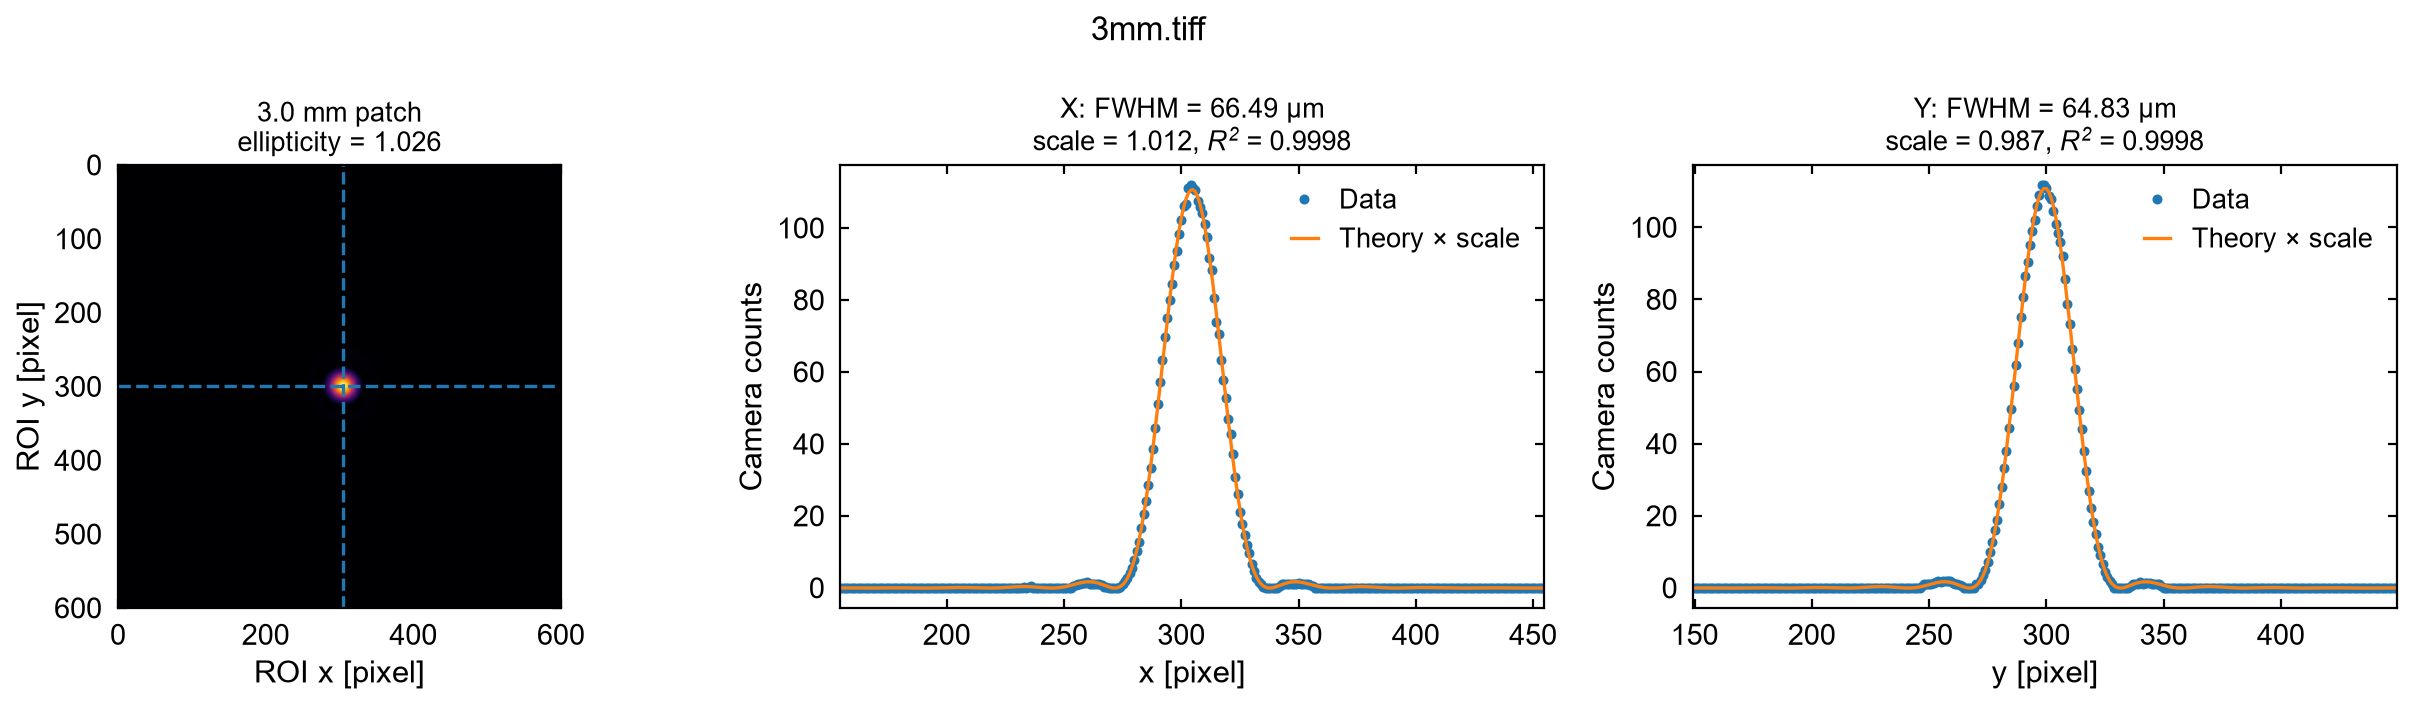


Plotting 5.0 mm ...


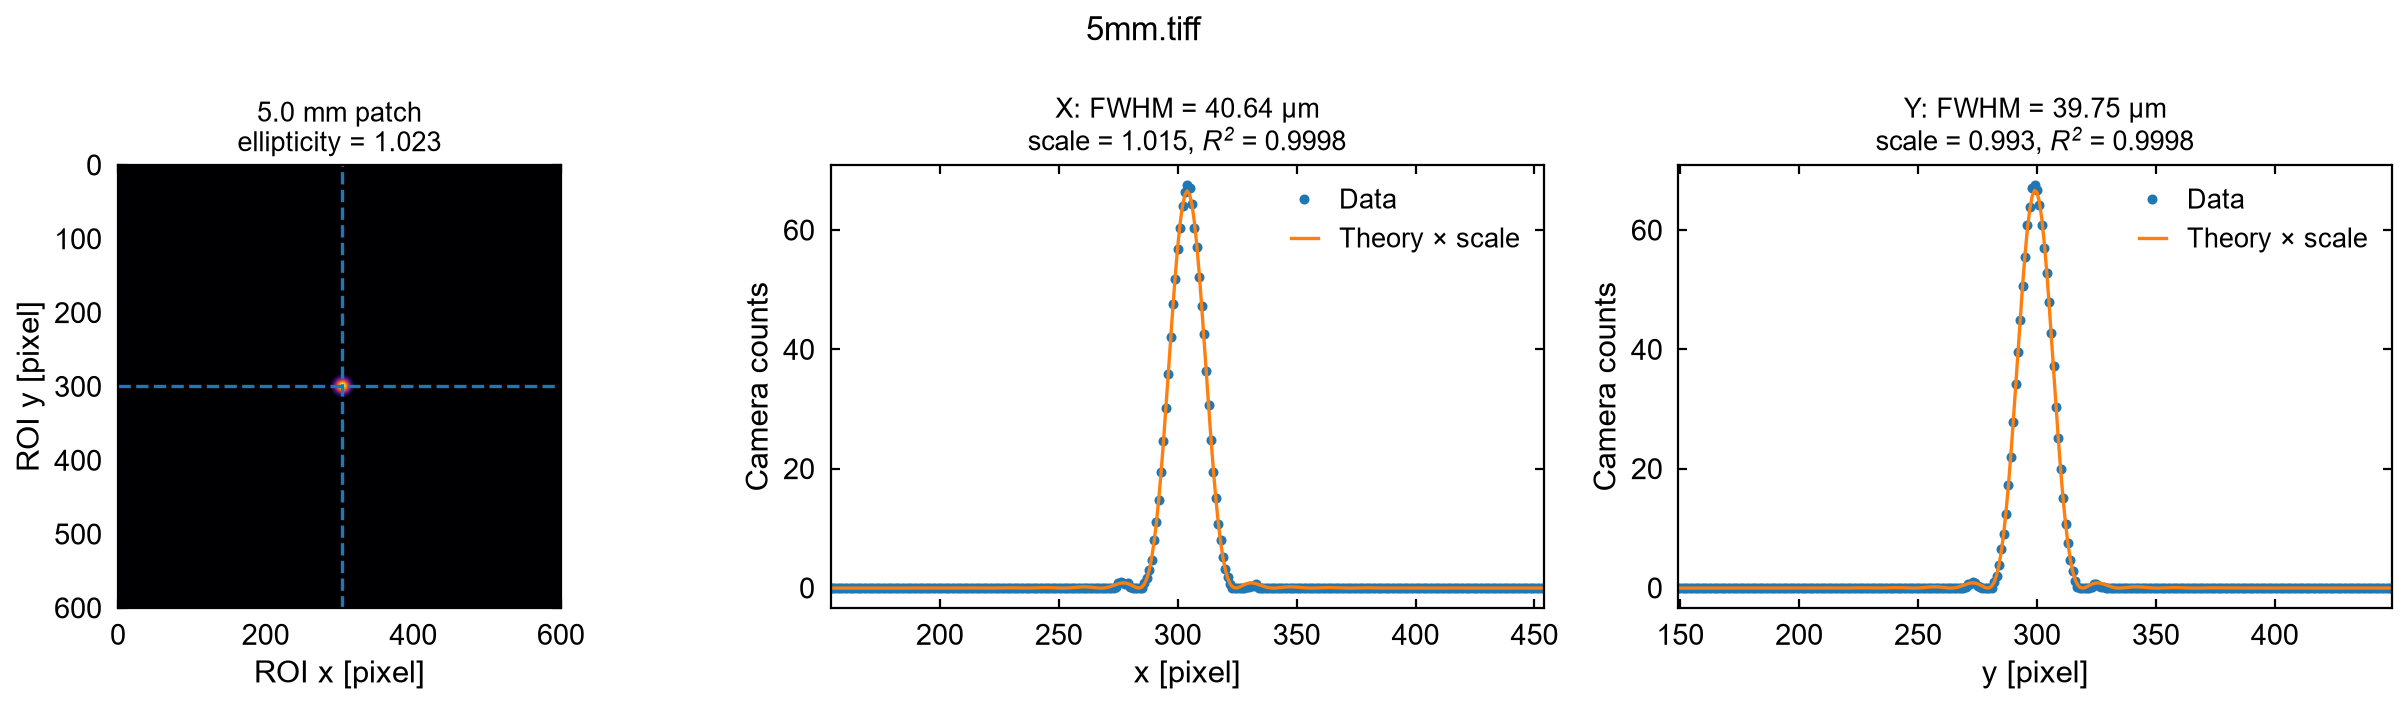


Plotting 7.0 mm ...


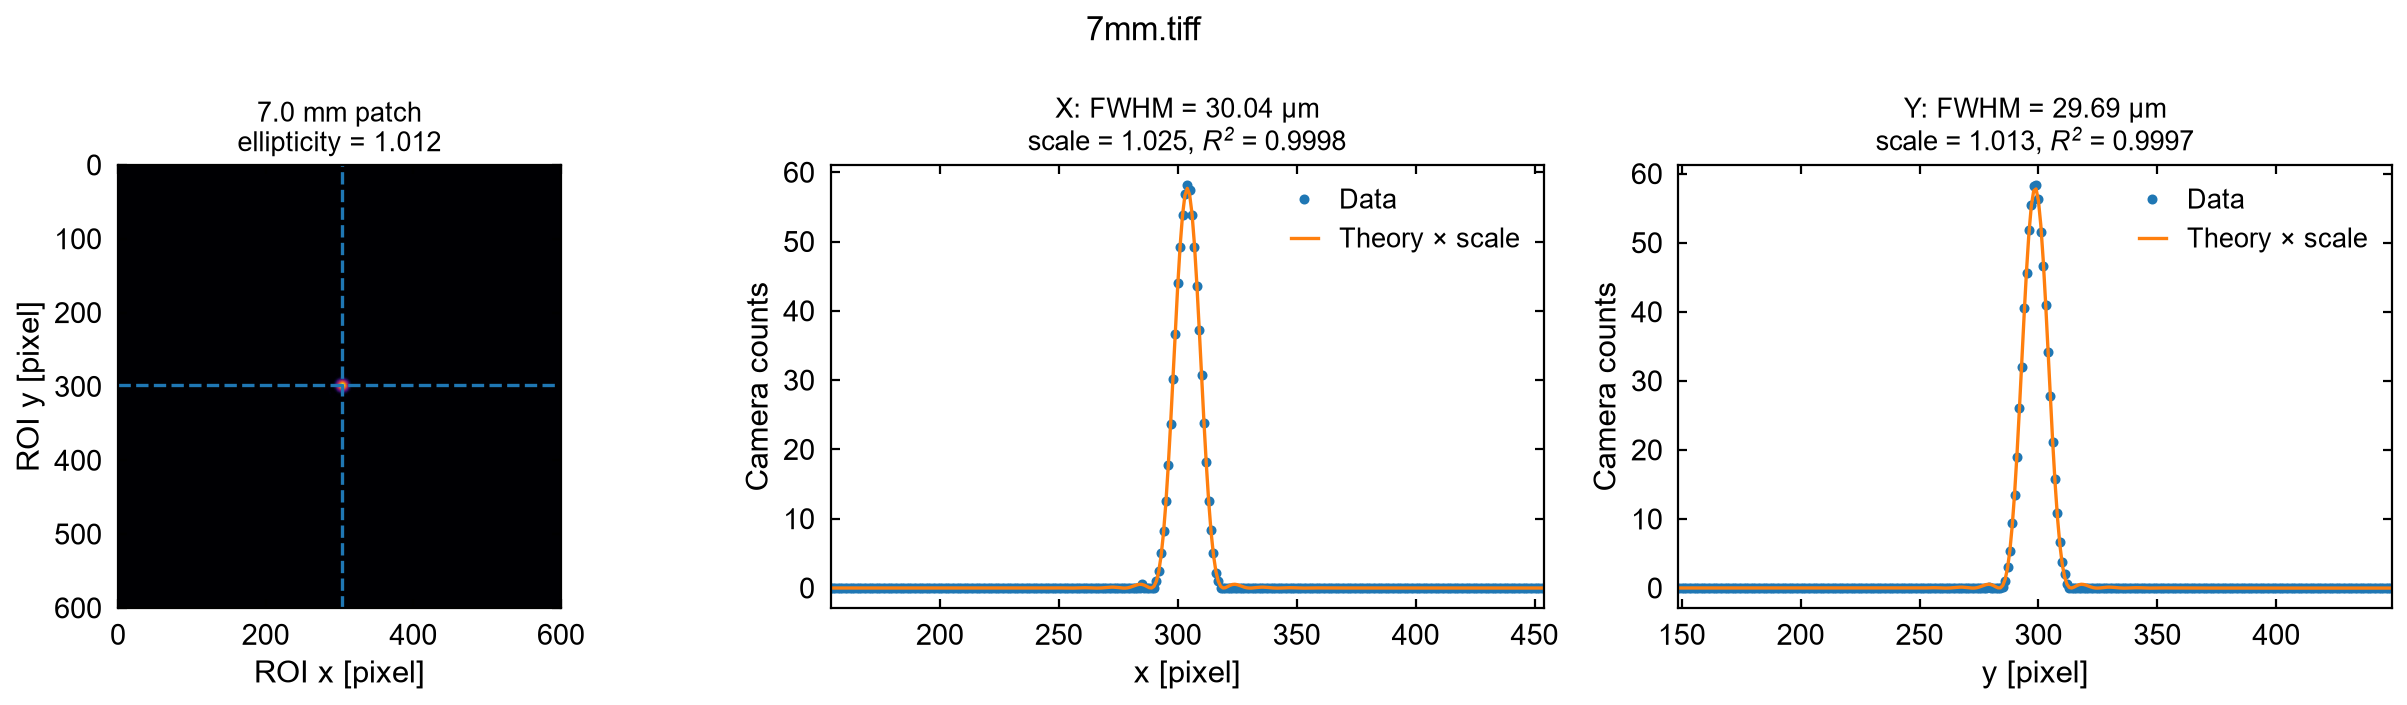


Plotting 9.0 mm ...


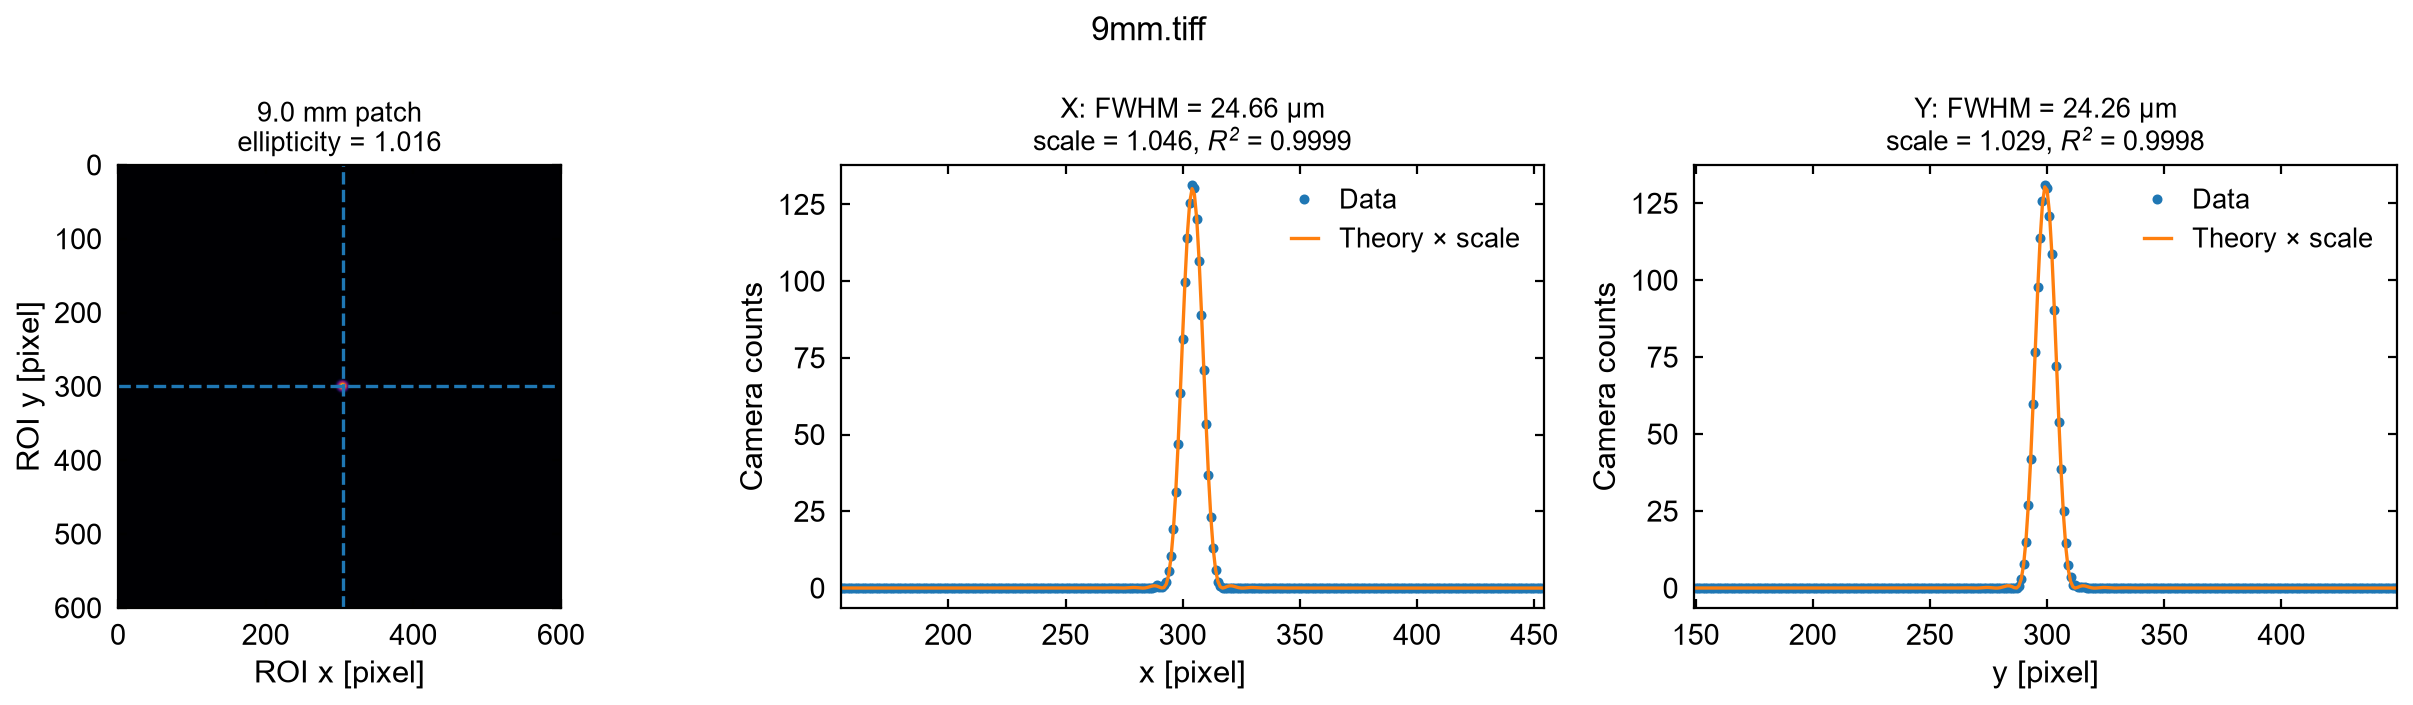


Plotting 9.6 mm ...


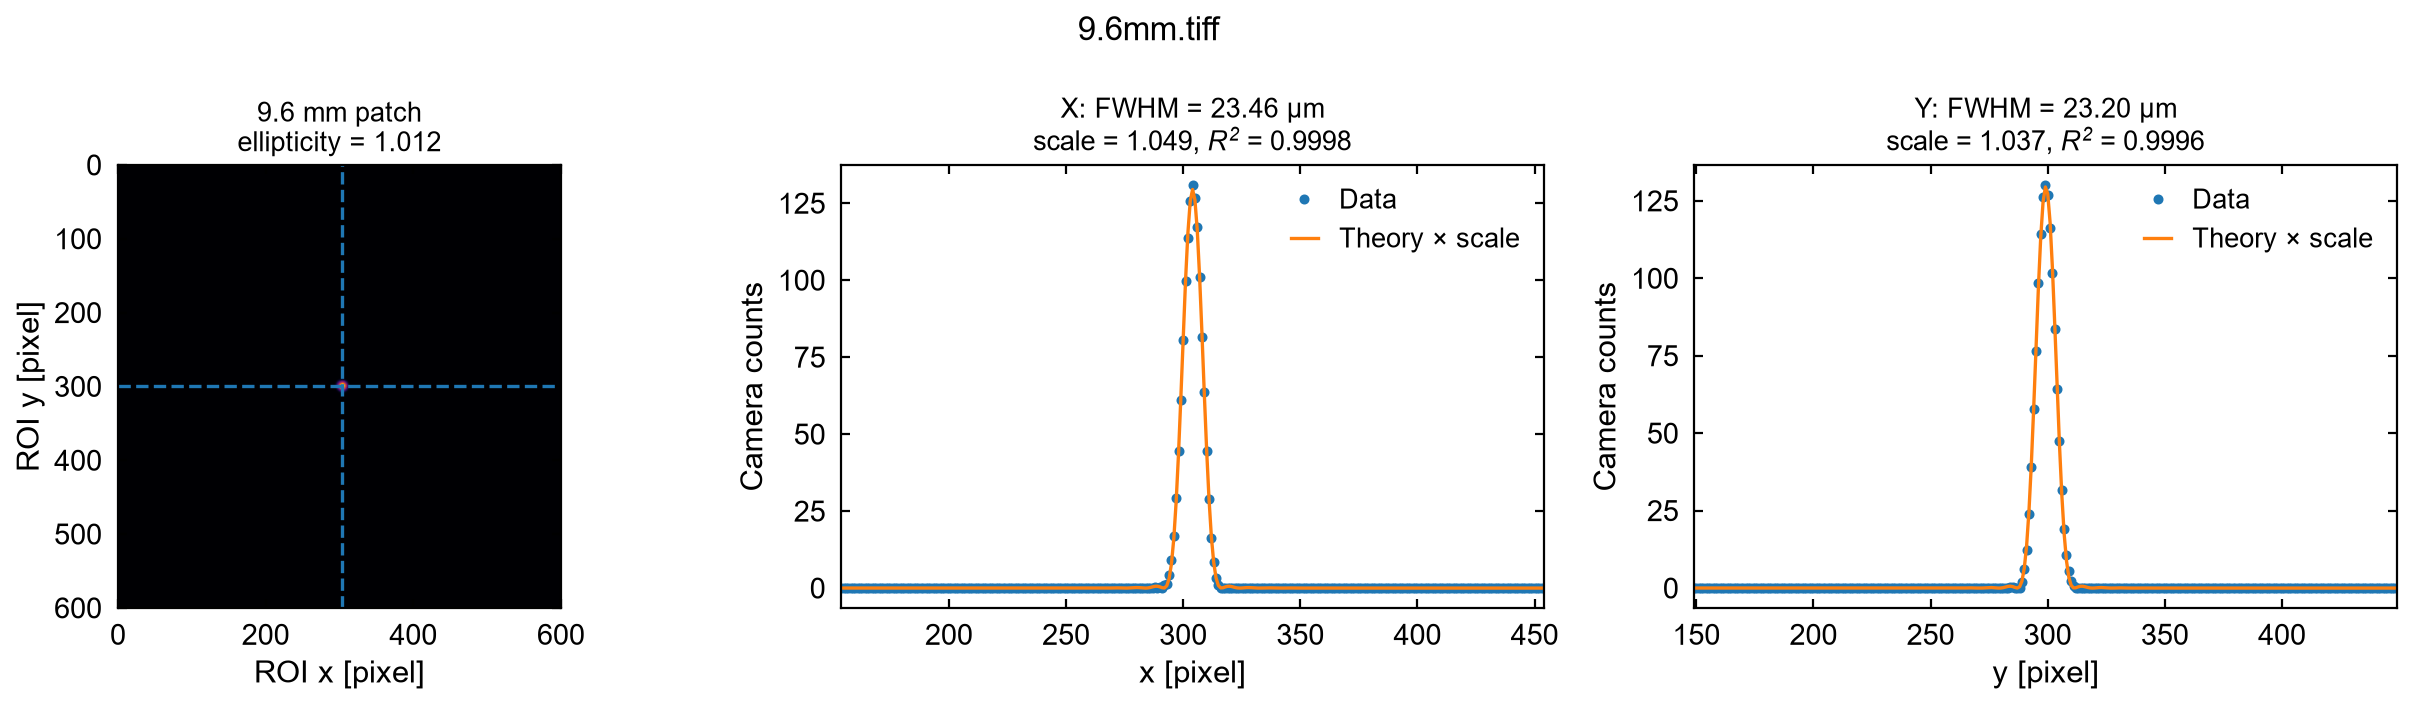


LARGEST PATCH SUMMARY
Patch diameter       : 9.60 mm
Theoretical FWHM     : 22.375 µm
Measured FWHM X      : 23.465 µm
Measured FWHM Y      : 23.197 µm
Scale X              : 1.0487
Scale Y              : 1.0367
Effective scale      : 1.0427
Ellipticity          : 1.0116
R² X                 : 0.99984
R² Y                 : 0.99963
Useful spot saturated: False


In [44]:
# ============================================================
# COMPLETE ANALYSIS — WAVEFRONT-CORRECTED SLM PATCH SCAN
#
# Measures how closely the useful +1-order Fourier spot agrees
# with the diffraction-limited truncated-Gaussian prediction.
#
# IMPORTANT:
# - Full camera frame may contain a saturated zeroth order.
# - We analyze ONLY the useful 16-pixel-carrier region near
#       x ~ 3731 px
#       y ~ 1822 px
#
# Outputs:
# - CSV table
# - FWHM vs patch diameter
# - measured/theoretical FWHM
# - ellipticity
# - centroid motion
# - R^2 fit quality
# - selected example fit plots
# ============================================================


from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.optimize import curve_fit
from scipy.special import j0


# ============================================================
# USER SETTINGS
# ============================================================

# ------------------------------------------------------------
# CHANGE THIS TO TODAY'S DATA FOLDER
# ------------------------------------------------------------

FOLDER = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\Alignment\04Sept\after wavefront correction patch size scan"
)

# ------------------------------------------------------------
# Optical parameters
# ------------------------------------------------------------

WAVELENGTH_NM = 759.3
FOCAL_LENGTH_MM = 250.0

CAMERA_PIXEL_UM = 2.4

# Input Gaussian beam on SLM:
# measured 1/e^2 INTENSITY diameter
BEAM_DIAMETER_MM = 9.6
BEAM_RADIUS_MM = BEAM_DIAMETER_MM / 2


# ------------------------------------------------------------
# Useful +1 order position
#
# From post-wavefront Fourier calibration:
# carrier ≈ (3731.218, 1821.689)
# ------------------------------------------------------------

CARRIER_X_PX = 3731.218
CARRIER_Y_PX = 1821.689


# Half-width of camera crop around useful order.
#
# 300 px is large enough even for ~0.5–1 mm patches,
# while the zero order ~631 px away remains outside.
ROI_HALF_WIDTH = 300


# Average this many pixels transverse to each line profile.
PROFILE_AVERAGE_WIDTH = 5


# Allowed measured / theoretical broadening.
MIN_SCALE = 0.3
MAX_SCALE = 5.0


IMAGE_EXTENSIONS = {
    ".bmp",
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
}


# ------------------------------------------------------------
# Which individual images should be plotted with their fits?
# Change if desired.
# ------------------------------------------------------------

EXAMPLE_PATCHES_MM = [1.0, 3.0, 5.0, 7.0, 9.0, 9.6]


# ============================================================
# PHYSICAL CONSTANTS
# ============================================================

lambda_m = WAVELENGTH_NM * 1e-9
f_m = FOCAL_LENGTH_MM * 1e-3

w_slm_m = BEAM_RADIUS_MM * 1e-3


# ============================================================
# READ PATCH DIAMETER FROM FILENAME
#
# Handles:
#   1mm.tiff
#   1.5mm.tiff
#   9.6mm.tiff
# ============================================================

def get_patch_diameter(filename):

    match = re.search(
        r"([0-9]+(?:\.[0-9]+)?)\s*mm",
        filename.lower()
    )

    if match is None:
        return None

    return float(match.group(1))


# ============================================================
# LOAD IMAGE
# ============================================================

def load_image(path):

    raw = np.array(Image.open(path))

    original_dtype = raw.dtype

    # RGB -> grayscale if needed
    if raw.ndim == 3:
        raw = raw.astype(float).mean(axis=2)
    else:
        raw = raw.astype(float)

    # Sensor digital maximum
    if np.issubdtype(original_dtype, np.integer):
        max_possible = np.iinfo(original_dtype).max
    else:
        max_possible = np.nan

    return raw, max_possible


# ============================================================
# CROP AROUND USEFUL 16-PIXEL CARRIER
# ============================================================

def extract_carrier_roi(full_img):

    xc = int(round(CARRIER_X_PX))
    yc = int(round(CARRIER_Y_PX))

    x1 = max(
        0,
        xc - ROI_HALF_WIDTH
    )

    x2 = min(
        full_img.shape[1],
        xc + ROI_HALF_WIDTH + 1
    )

    y1 = max(
        0,
        yc - ROI_HALF_WIDTH
    )

    y2 = min(
        full_img.shape[0],
        yc + ROI_HALF_WIDTH + 1
    )

    roi = full_img[
        y1:y2,
        x1:x2
    ]

    return roi, x1, y1


# ============================================================
# ROBUST BACKGROUND ESTIMATE
# ============================================================

def estimate_background(img):

    # Low percentile works well even for broad spots.
    return np.percentile(
        img,
        5
    )


# ============================================================
# FIND SPOT CENTER
# ============================================================

def find_spot_center(img, background):

    signal = (
        img.astype(float)
        - background
    )

    signal[signal < 0] = 0

    # Brightest pixel
    y_peak, x_peak = np.unravel_index(
        np.argmax(signal),
        signal.shape
    )

    if signal.max() <= 0:
        return float(x_peak), float(y_peak)

    # Refine centroid using central high-signal region
    threshold = (
        0.10
        * signal.max()
    )

    weights = np.where(
        signal >= threshold,
        signal,
        0
    )

    yy, xx = np.indices(
        signal.shape
    )

    total = weights.sum()

    if total <= 0:
        return float(x_peak), float(y_peak)

    x_com = (
        np.sum(xx * weights)
        / total
    )

    y_com = (
        np.sum(yy * weights)
        / total
    )

    return x_com, y_com


# ============================================================
# IDEAL TRUNCATED-GAUSSIAN FOURIER PSF
# ============================================================

def calculate_ideal_psf(
    patch_diameter_mm,
    rho_max_um,
    n_rho=2500,
    n_slm=2000
):
    """
    Fraunhofer intensity from

        E(r) = exp[-(r/w)^2]

    truncated by circular SLM patch

        r <= D/2.

    Input intensity is therefore

        I(r) = exp[-2(r/w)^2].

    The far-field radial amplitude is the Hankel transform

        E_f(rho) ∝ ∫ r E(r) J0(qr) dr

    with

        q = 2π rho / (lambda f).
    """

    R_m = (
        patch_diameter_mm
        * 1e-3
        / 2
    )

    # Radial SLM coordinate
    r = np.linspace(
        0,
        R_m,
        n_slm
    )

    # Gaussian FIELD amplitude
    amplitude_slm = np.exp(
        -(r / w_slm_m)**2
    )

    # Fourier-plane radial coordinate
    rho_um = np.linspace(
        0,
        rho_max_um,
        n_rho
    )

    rho_m = (
        rho_um
        * 1e-6
    )

    q = (
        2
        * np.pi
        * rho_m
        / (lambda_m * f_m)
    )

    qr = (
        q[:, None]
        * r[None, :]
    )

    integrand = (
        amplitude_slm[None, :]
        * j0(qr)
        * r[None, :]
    )

    field = np.trapezoid(
        integrand,
        r,
        axis=1
    )

    intensity = (
        np.abs(field)**2
    )

    intensity /= intensity[0]

    return rho_um, intensity


# ============================================================
# THEORETICAL FWHM
# ============================================================

def find_fwhm_from_radial_psf(
    rho_um,
    intensity
):

    below = np.where(
        intensity <= 0.5
    )[0]

    if len(below) == 0:
        return np.nan

    i = below[0]

    if i == 0:
        return np.nan

    x1 = rho_um[i - 1]
    x2 = rho_um[i]

    y1 = intensity[i - 1]
    y2 = intensity[i]

    # Linear interpolation to 0.5
    r_half = (
        x1
        +
        (0.5 - y1)
        * (x2 - x1)
        / (y2 - y1)
    )

    # radial half-width -> full width
    return (
        2 * r_half
    )


# ============================================================
# FIT MODEL
# ============================================================

def make_profile_model(
    rho_um,
    ideal_intensity
):

    def model(
        pixel_coordinate,
        amplitude,
        center,
        scale,
        background
    ):

        distance_um = (
            np.abs(
                pixel_coordinate
                - center
            )
            * CAMERA_PIXEL_UM
        )

        # scale > 1:
        # measured spot broader than ideal
        ideal_coordinate = (
            distance_um
            / scale
        )

        psf = np.interp(
            ideal_coordinate,
            rho_um,
            ideal_intensity,
            left=1.0,
            right=0.0
        )

        return (
            background
            + amplitude * psf
        )

    return model


# ============================================================
# R^2
# ============================================================

def calculate_r2(
    data,
    fit
):

    ss_res = np.sum(
        (data - fit)**2
    )

    ss_tot = np.sum(
        (
            data
            - np.mean(data)
        )**2
    )

    if ss_tot == 0:
        return np.nan

    return (
        1
        - ss_res / ss_tot
    )


# ============================================================
# ANALYZE ONE IMAGE
# ============================================================

def analyse_image(
    path,
    patch_diameter_mm,
    plot=False
):

    # --------------------------------------------------------
    # Load full camera frame
    # --------------------------------------------------------

    full_img, max_possible = load_image(
        path
    )

    full_frame_max = (
        np.max(full_img)
    )


    # --------------------------------------------------------
    # Extract useful carrier ROI
    # --------------------------------------------------------

    img, roi_x0, roi_y0 = extract_carrier_roi(
        full_img
    )

    ny, nx = img.shape


    # --------------------------------------------------------
    # Background
    # --------------------------------------------------------

    background = estimate_background(
        img
    )


    # --------------------------------------------------------
    # Locate useful carrier spot
    # --------------------------------------------------------

    x_center, y_center = find_spot_center(
        img,
        background
    )

    xc = int(
        round(x_center)
    )

    yc = int(
        round(y_center)
    )


    # Absolute full-camera coordinates
    x_center_full_guess = (
        roi_x0
        + x_center
    )

    y_center_full_guess = (
        roi_y0
        + y_center
    )


    # --------------------------------------------------------
    # Generate X / Y line profiles
    # --------------------------------------------------------

    half = (
        PROFILE_AVERAGE_WIDTH
        // 2
    )

    # X profile:
    # average a few rows around the spot
    y1 = max(
        0,
        yc - half
    )

    y2 = min(
        ny,
        yc + half + 1
    )

    x_profile = np.mean(
        img[y1:y2, :],
        axis=0
    )


    # Y profile:
    # average a few columns around the spot
    x1 = max(
        0,
        xc - half
    )

    x2 = min(
        nx,
        xc + half + 1
    )

    y_profile = np.mean(
        img[:, x1:x2],
        axis=1
    )


    x_pixels = np.arange(nx)
    y_pixels = np.arange(ny)


    # --------------------------------------------------------
    # Ideal truncated-Gaussian PSF
    # --------------------------------------------------------

    max_radius_um = (
        max(nx, ny)
        * CAMERA_PIXEL_UM
        * 1.5
    )

    rho_um, ideal_psf = calculate_ideal_psf(
        patch_diameter_mm,
        max_radius_um
    )

    theoretical_fwhm_um = (
        find_fwhm_from_radial_psf(
            rho_um,
            ideal_psf
        )
    )

    theoretical_fwhm_px = (
        theoretical_fwhm_um
        / CAMERA_PIXEL_UM
    )


    # Uniform circular aperture Airy reference
    D_m = (
        patch_diameter_mm
        * 1e-3
    )

    airy_fwhm_um = (
        1.028
        * lambda_m
        * f_m
        / D_m
        * 1e6
    )


    # --------------------------------------------------------
    # Fit model
    # --------------------------------------------------------

    model = make_profile_model(
        rho_um,
        ideal_psf
    )


    # ========================================================
    # FIT X
    # ========================================================

    p0_x = [
        x_profile.max() - background,
        x_center,
        1.0,
        background
    ]

    bounds_x = (
        [
            0,
            max(
                0,
                x_center - 30
            ),
            MIN_SCALE,
            -np.inf
        ],
        [
            np.inf,
            min(
                nx - 1,
                x_center + 30
            ),
            MAX_SCALE,
            np.inf
        ]
    )

    popt_x, pcov_x = curve_fit(
        model,
        x_pixels,
        x_profile,
        p0=p0_x,
        bounds=bounds_x,
        maxfev=50000
    )

    amp_x, x0_fit, scale_x, bg_x = (
        popt_x
    )

    x_fit = model(
        x_pixels,
        *popt_x
    )


    # ========================================================
    # FIT Y
    # ========================================================

    p0_y = [
        y_profile.max() - background,
        y_center,
        1.0,
        background
    ]

    bounds_y = (
        [
            0,
            max(
                0,
                y_center - 30
            ),
            MIN_SCALE,
            -np.inf
        ],
        [
            np.inf,
            min(
                ny - 1,
                y_center + 30
            ),
            MAX_SCALE,
            np.inf
        ]
    )

    popt_y, pcov_y = curve_fit(
        model,
        y_pixels,
        y_profile,
        p0=p0_y,
        bounds=bounds_y,
        maxfev=50000
    )

    amp_y, y0_fit, scale_y, bg_y = (
        popt_y
    )

    y_fit = model(
        y_pixels,
        *popt_y
    )


    # --------------------------------------------------------
    # Convert centers to full-camera coordinates
    # --------------------------------------------------------

    x0_fit_full = (
        roi_x0
        + x0_fit
    )

    y0_fit_full = (
        roi_y0
        + y0_fit
    )


    # --------------------------------------------------------
    # FWHM
    # --------------------------------------------------------

    fwhm_x_um = (
        scale_x
        * theoretical_fwhm_um
    )

    fwhm_y_um = (
        scale_y
        * theoretical_fwhm_um
    )

    fwhm_x_px = (
        fwhm_x_um
        / CAMERA_PIXEL_UM
    )

    fwhm_y_px = (
        fwhm_y_um
        / CAMERA_PIXEL_UM
    )


    # --------------------------------------------------------
    # Ellipticity
    # --------------------------------------------------------

    ellipticity = (
        max(
            fwhm_x_um,
            fwhm_y_um
        )
        /
        min(
            fwhm_x_um,
            fwhm_y_um
        )
    )


    # --------------------------------------------------------
    # Effective geometric-mean FWHM
    # --------------------------------------------------------

    fwhm_eff_um = np.sqrt(
        fwhm_x_um
        * fwhm_y_um
    )

    scale_eff = (
        fwhm_eff_um
        / theoretical_fwhm_um
    )


    # --------------------------------------------------------
    # Fit quality
    # --------------------------------------------------------

    r2_x = calculate_r2(
        x_profile,
        x_fit
    )

    r2_y = calculate_r2(
        y_profile,
        y_fit
    )


    # --------------------------------------------------------
    # Saturation of useful spot ONLY
    # --------------------------------------------------------

    carrier_peak = (
        np.max(img)
    )

    if np.isfinite(max_possible):

        saturated = (
            carrier_peak
            >= 0.98 * max_possible
        )

    else:

        saturated = False


    # --------------------------------------------------------
    # Optional individual diagnostic plot
    # --------------------------------------------------------

    if plot:

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(16, 4.5)
        )


        # ------------------------------
        # ROI image
        # ------------------------------

        axes[0].imshow(
            img,
            origin="upper",
            cmap="inferno"
        )

        axes[0].axvline(
            x0_fit,
            linestyle="--"
        )

        axes[0].axhline(
            y0_fit,
            linestyle="--"
        )

        axes[0].set_title(
            f"{patch_diameter_mm:.1f} mm patch\n"
            f"ellipticity = {ellipticity:.3f}"
        )

        axes[0].set_xlabel(
            "ROI x [pixel]"
        )

        axes[0].set_ylabel(
            "ROI y [pixel]"
        )


        # ------------------------------
        # X
        # ------------------------------

        axes[1].plot(
            x_pixels,
            x_profile,
            ".",
            label="Data"
        )

        axes[1].plot(
            x_pixels,
            x_fit,
            "-",
            label="Theory × scale"
        )

        axes[1].set_xlim(
            x0_fit - 150,
            x0_fit + 150
        )

        axes[1].set_title(
            f"X: FWHM = {fwhm_x_um:.2f} µm\n"
            f"scale = {scale_x:.3f}, "
            f"$R^2$ = {r2_x:.4f}"
        )

        axes[1].set_xlabel(
            "x [pixel]"
        )

        axes[1].set_ylabel(
            "Camera counts"
        )

        axes[1].legend()


        # ------------------------------
        # Y
        # ------------------------------

        axes[2].plot(
            y_pixels,
            y_profile,
            ".",
            label="Data"
        )

        axes[2].plot(
            y_pixels,
            y_fit,
            "-",
            label="Theory × scale"
        )

        axes[2].set_xlim(
            y0_fit - 150,
            y0_fit + 150
        )

        axes[2].set_title(
            f"Y: FWHM = {fwhm_y_um:.2f} µm\n"
            f"scale = {scale_y:.3f}, "
            f"$R^2$ = {r2_y:.4f}"
        )

        axes[2].set_xlabel(
            "y [pixel]"
        )

        axes[2].set_ylabel(
            "Camera counts"
        )

        axes[2].legend()


        fig.suptitle(
            path.name
        )

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return {

        "filename":
            path.name,

        "patch_mm":
            patch_diameter_mm,

        "x_center_px":
            x0_fit_full,

        "y_center_px":
            y0_fit_full,

        "theory_fwhm_um":
            theoretical_fwhm_um,

        "airy_fwhm_um":
            airy_fwhm_um,

        "fwhm_x_um":
            fwhm_x_um,

        "fwhm_y_um":
            fwhm_y_um,

        "fwhm_eff_um":
            fwhm_eff_um,

        "fwhm_x_px":
            fwhm_x_px,

        "fwhm_y_px":
            fwhm_y_px,

        # diffraction quality:
        # ideal = 1
        "scale_x":
            scale_x,

        "scale_y":
            scale_y,

        "scale_eff":
            scale_eff,

        "ellipticity":
            ellipticity,

        "R2_x":
            r2_x,

        "R2_y":
            r2_y,

        "carrier_peak_counts":
            carrier_peak,

        "full_frame_peak_counts":
            full_frame_max,

        "saturated":
            saturated
    }


# ============================================================
# FIND ALL PATCH IMAGES
# ============================================================

files = []

for path in FOLDER.iterdir():

    if (
        path.suffix.lower()
        not in IMAGE_EXTENSIONS
    ):
        continue

    diameter = get_patch_diameter(
        path.name
    )

    if diameter is None:

        print(
            "Skipping: could not determine patch size:",
            path.name
        )

        continue

    files.append(
        (diameter, path)
    )


files.sort(
    key=lambda item: item[0]
)


print()
print("Found images:")

for diameter, path in files:

    print(
        f"{diameter:4.1f} mm : {path.name}"
    )


# ============================================================
# RUN BATCH ANALYSIS
# ============================================================

results = []

for diameter, path in files:

    print()
    print(
        f"Analysing {diameter:.1f} mm ..."
    )

    try:

        result = analyse_image(
            path,
            diameter,
            plot=False
        )

        results.append(
            result
        )

    except Exception as exc:

        print(
            "FIT FAILED:",
            path.name,
            exc
        )


df = pd.DataFrame(
    results
)

df = df.sort_values(
    "patch_mm"
).reset_index(
    drop=True
)


# ============================================================
# PRINT TABLE
# ============================================================

columns_to_show = [

    "patch_mm",

    "theory_fwhm_um",

    "fwhm_x_um",
    "fwhm_y_um",

    "scale_x",
    "scale_y",
    "scale_eff",

    "ellipticity",

    "R2_x",
    "R2_y",

    "carrier_peak_counts",

    "saturated"
]


print()
print("=" * 120)

print(
    "WAVEFRONT-CORRECTED PATCH SCAN RESULTS"
)

print("=" * 120)


print(
    df[
        columns_to_show
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SAVE CSV
# ============================================================

csv_path = (
    FOLDER
    / "SLM_patch_analysis_wavefront_corrected.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print()
print(
    "Saved results to:"
)

print(
    csv_path
)


# ============================================================
# PLOT 1
# FWHM vs patch diameter
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    df["patch_mm"],
    df["theory_fwhm_um"],
    "k--",
    linewidth=2,
    label="Ideal truncated-Gaussian"
)

plt.plot(
    df["patch_mm"],
    df["airy_fwhm_um"],
    ":",
    linewidth=1.5,
    label="Uniform-aperture Airy"
)

plt.plot(
    df["patch_mm"],
    df["fwhm_x_um"],
    "o-",
    label="Measured X"
)

plt.plot(
    df["patch_mm"],
    df["fwhm_y_um"],
    "o-",
    label="Measured Y"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "FWHM at camera [µm]"
)

plt.title(
    "Wavefront corrected: Fourier spot width"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 2
# MEASURED / DIFFRACTION-LIMITED FWHM
#
# This is probably the most important plot.
#
# Ideal = 1.
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.axhline(
    1,
    linestyle="--",
    label="Diffraction limited"
)

plt.plot(
    df["patch_mm"],
    df["scale_x"],
    "o-",
    label="X"
)

plt.plot(
    df["patch_mm"],
    df["scale_y"],
    "o-",
    label="Y"
)

plt.plot(
    df["patch_mm"],
    df["scale_eff"],
    "s-",
    label="Geometric mean"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Measured / theoretical FWHM"
)

plt.title(
    "Wavefront corrected: departure from diffraction limit"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 3
# ELLIPTICITY
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.axhline(
    1,
    linestyle="--",
    label="Circular"
)

plt.plot(
    df["patch_mm"],
    df["ellipticity"],
    "o-"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    r"$\max(\mathrm{FWHM}_x,\mathrm{FWHM}_y)"
    r"/\min(\mathrm{FWHM}_x,\mathrm{FWHM}_y)$"
)

plt.title(
    "Wavefront corrected: spot ellipticity"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 4
# CENTROID SHIFT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

x_reference = (
    df["x_center_px"].iloc[0]
)

y_reference = (
    df["y_center_px"].iloc[0]
)


plt.plot(
    df["patch_mm"],
    df["x_center_px"]
    - x_reference,
    "o-",
    label="X centroid"
)

plt.plot(
    df["patch_mm"],
    df["y_center_px"]
    - y_reference,
    "o-",
    label="Y centroid"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Centroid shift [camera pixels]"
)

plt.title(
    "Carrier spot position vs illuminated SLM diameter"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 5
# FIT QUALITY
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    df["patch_mm"],
    df["R2_x"],
    "o-",
    label="X"
)

plt.plot(
    df["patch_mm"],
    df["R2_y"],
    "o-",
    label="Y"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    r"$R^2$"
)

plt.title(
    "Agreement with ideal truncated-Gaussian PSF"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 6
# CARRIER PEAK COUNTS
#
# Only meaningful if camera exposure / laser power was
# unchanged between images.
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    df["patch_mm"],
    df["carrier_peak_counts"],
    "o-"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Useful carrier peak [camera counts]"
)

plt.title(
    "Useful +1-order peak vs patch diameter"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# SELECTED EXAMPLE FITS
# ============================================================

print()
print("=" * 80)
print("SELECTED FIT EXAMPLES")
print("=" * 80)

for requested_diameter in EXAMPLE_PATCHES_MM:

    matches = [
        (d, p)
        for d, p in files
        if np.isclose(
            d,
            requested_diameter,
            atol=1e-6
        )
    ]

    if len(matches) == 0:
        continue

    diameter, path = matches[0]

    print()
    print(
        f"Plotting {diameter:.1f} mm ..."
    )

    analyse_image(
        path,
        diameter,
        plot=True
    )


# ============================================================
# FINAL LARGE-APERTURE SUMMARY
# ============================================================

if len(df) > 0:

    last = (
        df.iloc[-1]
    )

    print()
    print("=" * 80)
    print("LARGEST PATCH SUMMARY")
    print("=" * 80)

    print(
        f"Patch diameter       : "
        f"{last['patch_mm']:.2f} mm"
    )

    print(
        f"Theoretical FWHM     : "
        f"{last['theory_fwhm_um']:.3f} µm"
    )

    print(
        f"Measured FWHM X      : "
        f"{last['fwhm_x_um']:.3f} µm"
    )

    print(
        f"Measured FWHM Y      : "
        f"{last['fwhm_y_um']:.3f} µm"
    )

    print(
        f"Scale X              : "
        f"{last['scale_x']:.4f}"
    )

    print(
        f"Scale Y              : "
        f"{last['scale_y']:.4f}"
    )

    print(
        f"Effective scale      : "
        f"{last['scale_eff']:.4f}"
    )

    print(
        f"Ellipticity          : "
        f"{last['ellipticity']:.4f}"
    )

    print(
        f"R² X                 : "
        f"{last['R2_x']:.5f}"
    )

    print(
        f"R² Y                 : "
        f"{last['R2_y']:.5f}"
    )

    print(
        f"Useful spot saturated: "
        f"{bool(last['saturated'])}"
    )


Wavefront OFF
Folder: C:\Users\admin\Desktop\Projects\SLM\Alignment\02Sept\slm_patch_scan

Found 19 images:
 1.0 mm : 1mm.tiff
 1.5 mm : 1.5mm.tiff
 2.0 mm : 2mm.tiff
 2.5 mm : 2.5mm.tiff
 3.0 mm : 3mm.tiff
 3.5 mm : 3.5mm.tiff
 4.0 mm : 4mm.tiff
 4.5 mm : 4.5mm.tiff
 5.0 mm : 5mm.tiff
 5.5 mm : 5.5mm.tiff
 6.0 mm : 6mm.tiff
 6.5 mm : 6.5mm.tiff
 7.0 mm : 7mm.tiff
 7.5 mm : 7.5mm.tiff
 8.0 mm : 8mm.tiff
 8.5 mm : 8.5mm.tiff
 9.0 mm : 9mm.tiff
 9.5 mm : 9.5mm.tiff
 9.6 mm : 9.6mm.tiff
Analysing Wavefront OFF: 1.0 mm ...
Analysing Wavefront OFF: 1.5 mm ...
Analysing Wavefront OFF: 2.0 mm ...
Analysing Wavefront OFF: 2.5 mm ...
Analysing Wavefront OFF: 3.0 mm ...
Analysing Wavefront OFF: 3.5 mm ...
Analysing Wavefront OFF: 4.0 mm ...
Analysing Wavefront OFF: 4.5 mm ...
Analysing Wavefront OFF: 5.0 mm ...
Analysing Wavefront OFF: 5.5 mm ...
Analysing Wavefront OFF: 6.0 mm ...
Analysing Wavefront OFF: 6.5 mm ...
Analysing Wavefront OFF: 7.0 mm ...
Analysing Wavefront OFF: 7.5 mm ...
Analys

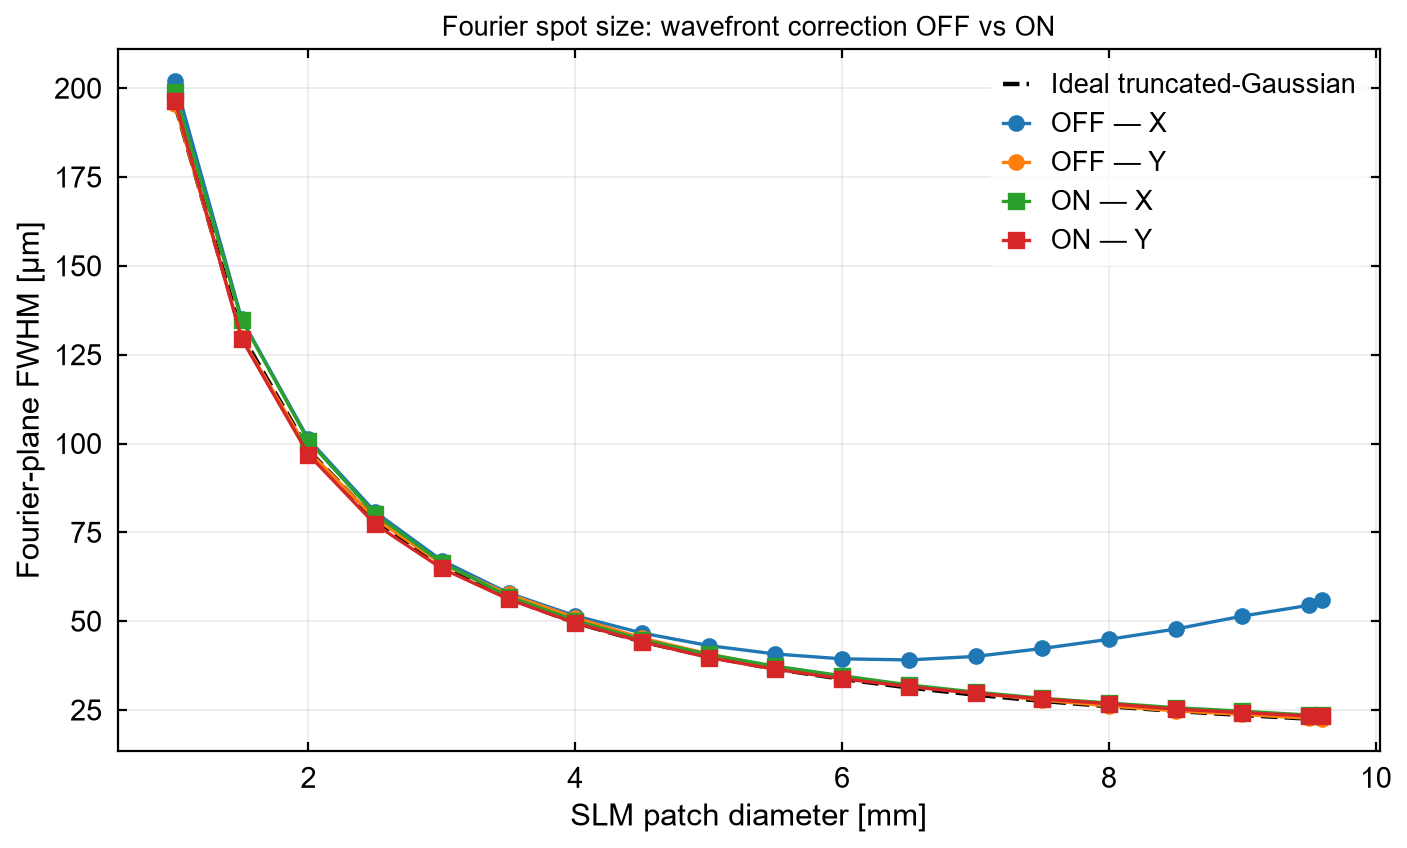

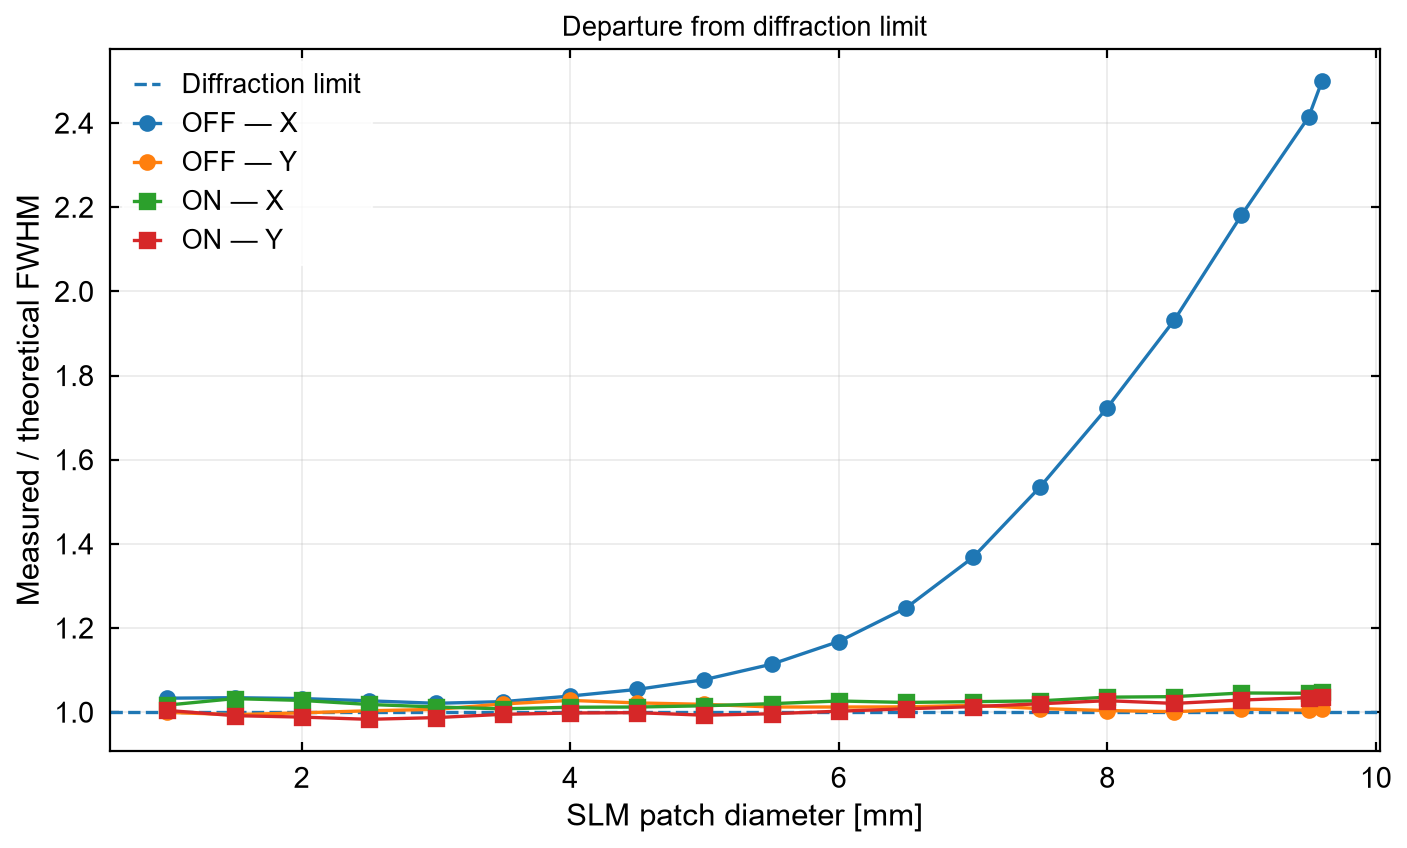

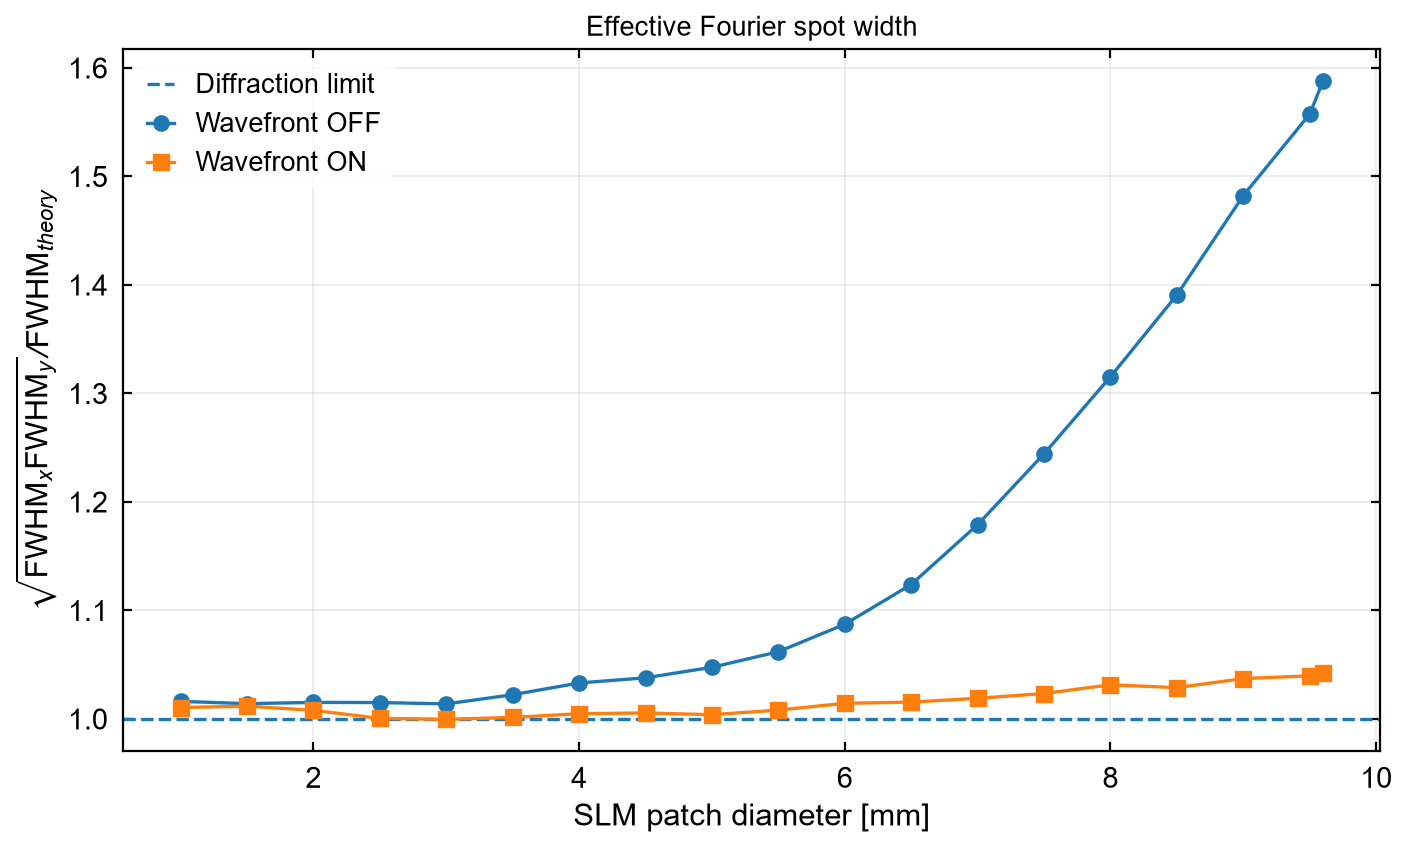

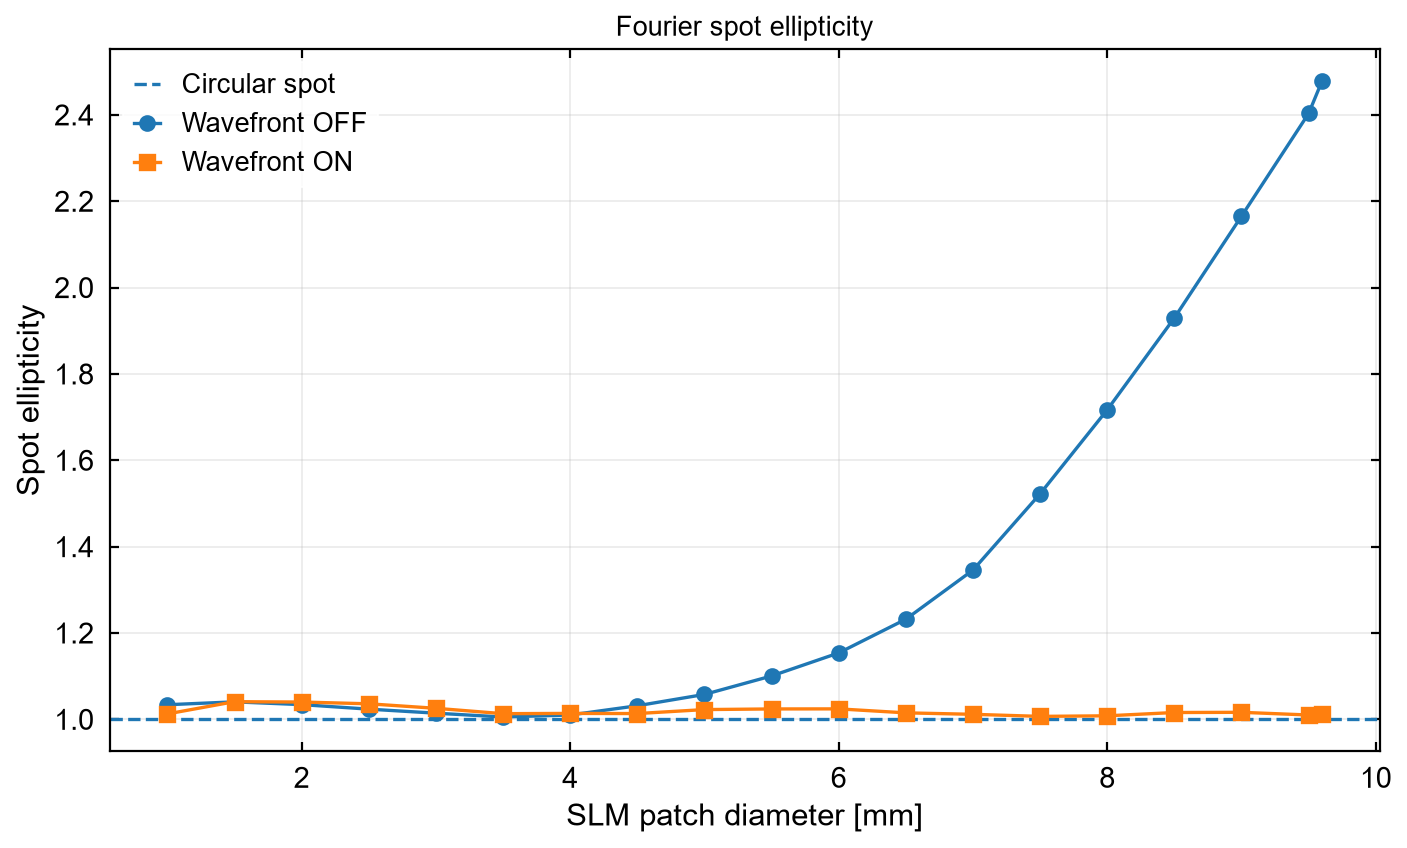

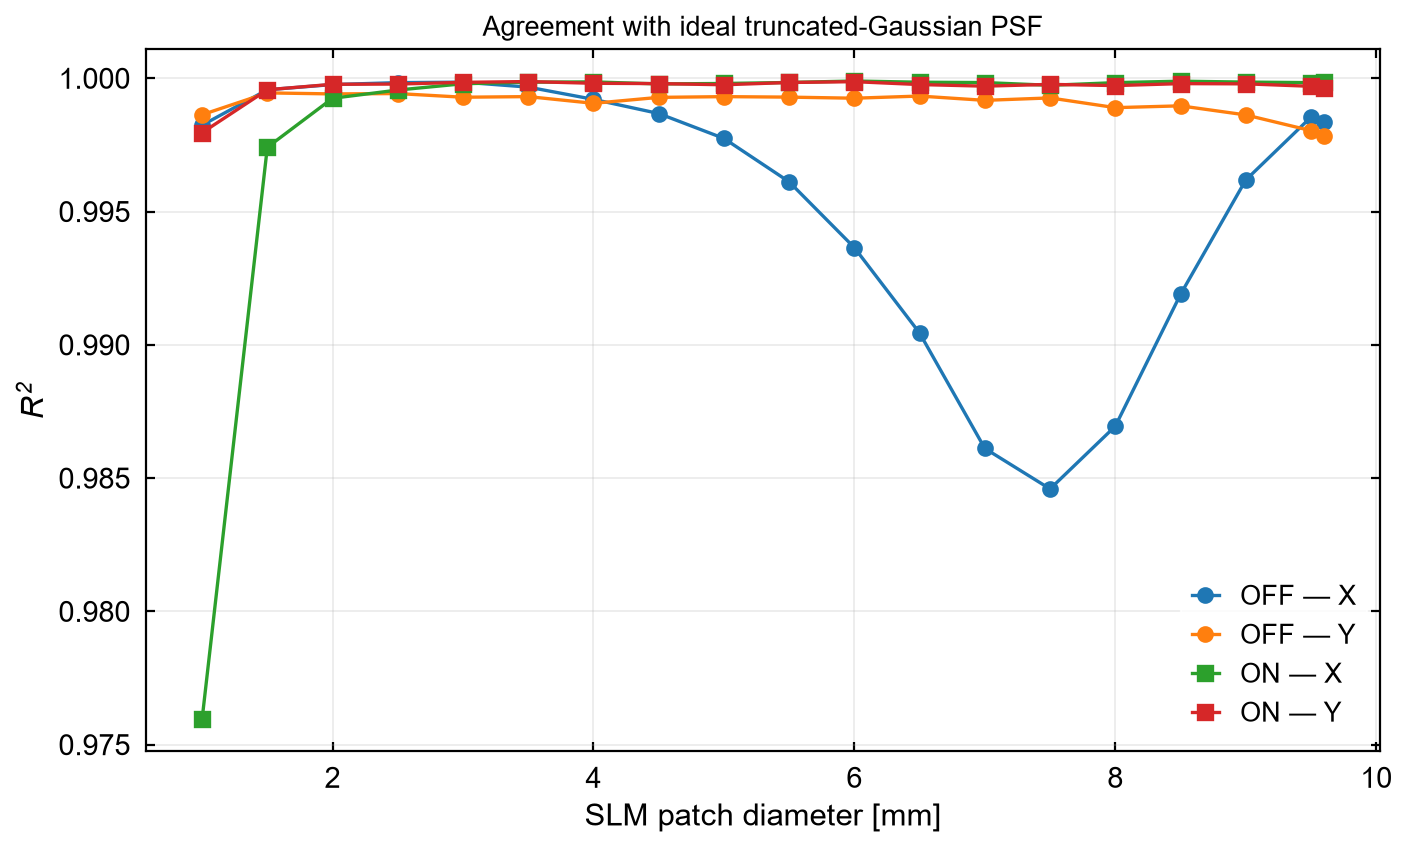

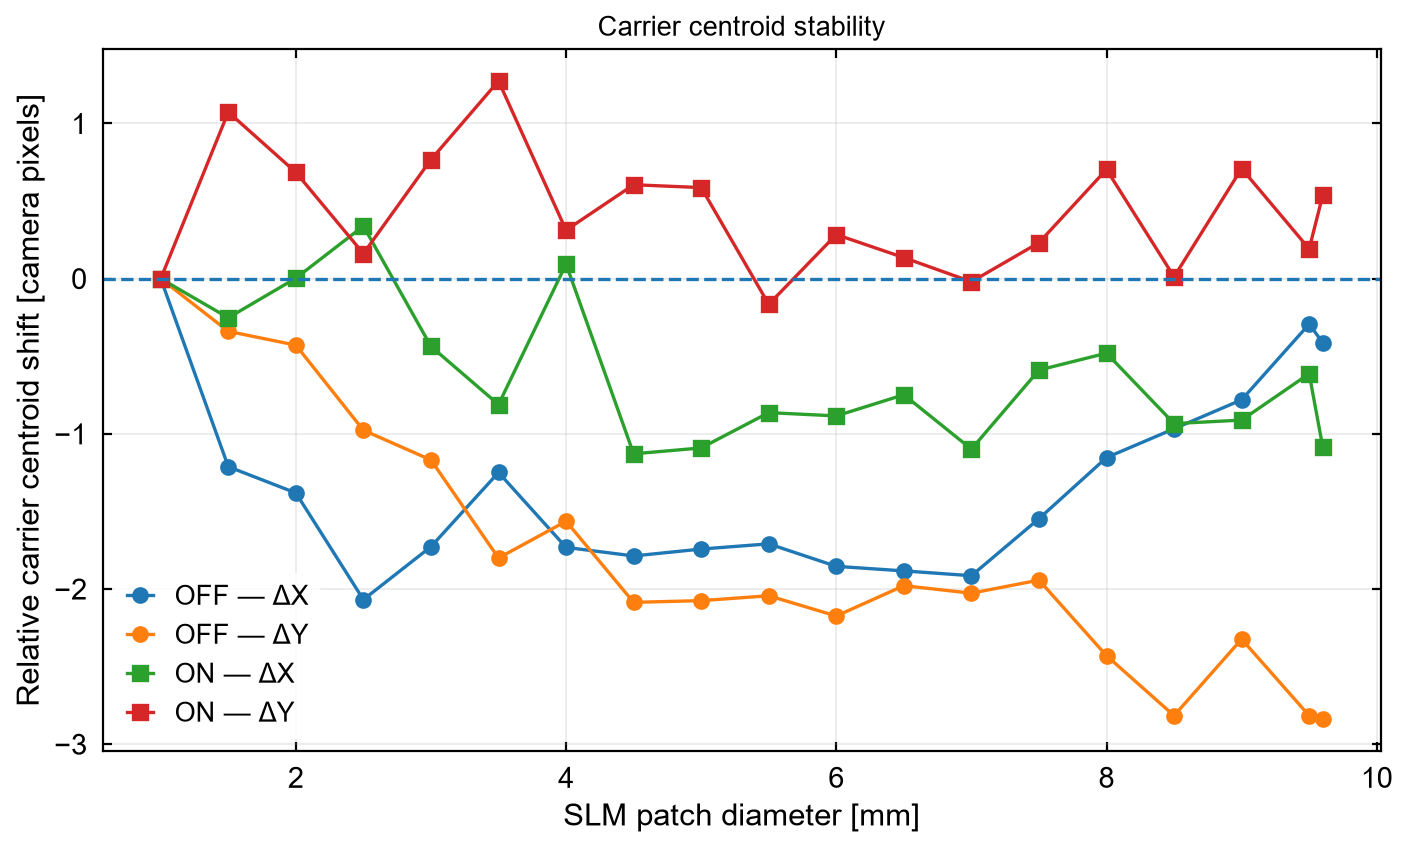


LARGEST COMMON PATCH: 9.60 mm
Theory FWHM: 22.374 µm

WAVEFRONT OFF
  FWHM X      : 55.937 µm
  FWHM Y      : 22.569 µm
  Scale X     : 2.5000
  Scale Y     : 1.0087
  Ellipticity : 2.4785

WAVEFRONT ON
  FWHM X      : 23.465 µm
  FWHM Y      : 23.197 µm
  Scale X     : 1.0487
  Scale Y     : 1.0367
  Ellipticity : 1.0116

IMPROVEMENT
  X width ON/OFF : 0.4195
  Y width ON/OFF : 1.0278
  Ellipticity: 2.479 -> 1.012


In [45]:
# ============================================================
# FINAL COMPARISON
# SLM PATCH SCAN — WAVEFRONT OFF vs WAVEFRONT ON
# ============================================================
#
# UNCORRECTED DATA:
#   Yesterday's files are already cropped around the useful
#   +1 carrier spot.
#
# CORRECTED DATA:
#   Today's files are full camera frames.
#   We crop around the known 16-pixel carrier position.
#
# Both datasets are then analyzed using EXACTLY THE SAME
# truncated-Gaussian Fourier PSF model.
#
# Main outputs:
#
#   1. FWHM vs patch diameter
#   2. Measured / theoretical FWHM
#   3. Effective spot-size scale
#   4. Ellipticity
#   5. Fit R^2
#   6. Relative centroid motion
#   7. Combined comparison table
#   8. CSVs
#
# ============================================================


from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.optimize import curve_fit
from scipy.special import j0


# ============================================================
# USER SETTINGS
# ============================================================

# ------------------------------------------------------------
# YESTERDAY — NO WAVEFRONT CORRECTION
#
# These images are already CROPPED around the carrier spot.
# ------------------------------------------------------------

UNCORRECTED_FOLDER = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\Alignment\02Sept\slm_patch_scan"
)


# ------------------------------------------------------------
# TODAY — WAVEFRONT CORRECTION ON
#
# CHANGE THIS TO THE FOLDER CONTAINING TODAY'S TIFF FILES.
# ------------------------------------------------------------

CORRECTED_FOLDER = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\Alignment\04Sept\after wavefront correction patch size scan"
)


# ============================================================
# OPTICAL PARAMETERS
# ============================================================

WAVELENGTH_NM = 759.3

FOCAL_LENGTH_MM = 250.0

CAMERA_PIXEL_UM = 2.4


# Input Gaussian beam on SLM
#
# measured 1/e^2 INTENSITY diameter
BEAM_DIAMETER_MM = 9.6

BEAM_RADIUS_MM = (
    BEAM_DIAMETER_MM / 2
)


# ============================================================
# TODAY'S FULL-FRAME CARRIER POSITION
#
# From post-wavefront Fourier calibration
# ============================================================

CARRIER_X_PX = 3731.218

CARRIER_Y_PX = 1821.689


# Crop used ONLY for today's full-frame images.
#
# Zeroth order is about 631 px away horizontally,
# so ±300 px safely excludes it.
ROI_HALF_WIDTH = 300


# Average this many pixels transverse to each line profile.
PROFILE_AVERAGE_WIDTH = 5


# Allowed measured/theoretical scale during fitting.
MIN_SCALE = 0.3
MAX_SCALE = 5.0


IMAGE_EXTENSIONS = {
    ".bmp",
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".tiff",
}


# ============================================================
# PHYSICAL CONSTANTS
# ============================================================

lambda_m = (
    WAVELENGTH_NM
    * 1e-9
)

f_m = (
    FOCAL_LENGTH_MM
    * 1e-3
)

w_slm_m = (
    BEAM_RADIUS_MM
    * 1e-3
)


# ============================================================
# READ PATCH DIAMETER FROM FILENAME
# ============================================================

def get_patch_diameter(filename):

    match = re.search(
        r"([0-9]+(?:\.[0-9]+)?)\s*mm",
        filename.lower()
    )

    if match is None:
        return None

    return float(
        match.group(1)
    )


# ============================================================
# LOAD IMAGE
# ============================================================

def load_image(path):

    raw = np.array(
        Image.open(path)
    )

    original_dtype = raw.dtype

    # RGB -> grayscale if required
    if raw.ndim == 3:

        raw = (
            raw.astype(float)
            .mean(axis=2)
        )

    else:

        raw = raw.astype(float)


    # Possible digital saturation level
    if np.issubdtype(
        original_dtype,
        np.integer
    ):

        max_possible = (
            np.iinfo(
                original_dtype
            ).max
        )

    else:

        max_possible = np.nan


    return (
        raw,
        max_possible
    )


# ============================================================
# PREPARE IMAGE FOR ANALYSIS
# ============================================================

def prepare_analysis_image(
    full_img,
    dataset_mode
):
    """
    dataset_mode:

        "cropped"
            Image is already an ROI around the useful carrier.

        "full_frame"
            Image is full camera frame and must be cropped
            around known +1-order carrier position.

    Returns:
        analysis_img,
        x_offset,
        y_offset
    """

    if dataset_mode == "cropped":

        # Yesterday's images:
        # already centered on useful spot.
        return (
            full_img,
            0,
            0
        )


    elif dataset_mode == "full_frame":

        xc = int(
            round(CARRIER_X_PX)
        )

        yc = int(
            round(CARRIER_Y_PX)
        )


        x1 = max(
            0,
            xc - ROI_HALF_WIDTH
        )

        x2 = min(
            full_img.shape[1],
            xc + ROI_HALF_WIDTH + 1
        )


        y1 = max(
            0,
            yc - ROI_HALF_WIDTH
        )

        y2 = min(
            full_img.shape[0],
            yc + ROI_HALF_WIDTH + 1
        )


        roi = full_img[
            y1:y2,
            x1:x2
        ]


        return (
            roi,
            x1,
            y1
        )


    else:

        raise ValueError(
            f"Unknown dataset_mode: {dataset_mode}"
        )


# ============================================================
# ROBUST BACKGROUND
# ============================================================

def estimate_background(img):

    return np.percentile(
        img,
        5
    )


# ============================================================
# FIND SPOT CENTER
# ============================================================

def find_spot_center(
    img,
    background
):

    signal = (
        img.astype(float)
        - background
    )

    signal[
        signal < 0
    ] = 0


    y_peak, x_peak = (
        np.unravel_index(
            np.argmax(signal),
            signal.shape
        )
    )


    if signal.max() <= 0:

        return (
            float(x_peak),
            float(y_peak)
        )


    threshold = (
        0.10
        * signal.max()
    )


    weights = np.where(
        signal >= threshold,
        signal,
        0
    )


    yy, xx = np.indices(
        signal.shape
    )


    total = (
        weights.sum()
    )


    if total <= 0:

        return (
            float(x_peak),
            float(y_peak)
        )


    x_com = (
        np.sum(
            xx * weights
        )
        / total
    )


    y_com = (
        np.sum(
            yy * weights
        )
        / total
    )


    return (
        x_com,
        y_com
    )


# ============================================================
# IDEAL TRUNCATED-GAUSSIAN FOURIER PSF
# ============================================================

def calculate_ideal_psf(
    patch_diameter_mm,
    rho_max_um,
    n_rho=2500,
    n_slm=2000
):
    """
    Input SLM field:

        E(r) = exp[-(r/w)^2]

    corresponding to intensity

        I(r) = exp[-2(r/w)^2]

    truncated at

        r <= D/2.

    Fourier-plane radial field:

        E_f(rho) ∝ integral r E(r) J0(qr) dr

    where

        q = 2π rho/(lambda f).
    """

    R_m = (
        patch_diameter_mm
        * 1e-3
        / 2
    )


    r = np.linspace(
        0,
        R_m,
        n_slm
    )


    amplitude_slm = np.exp(
        -(r / w_slm_m)**2
    )


    rho_um = np.linspace(
        0,
        rho_max_um,
        n_rho
    )


    rho_m = (
        rho_um
        * 1e-6
    )


    q = (
        2
        * np.pi
        * rho_m
        / (lambda_m * f_m)
    )


    qr = (
        q[:, None]
        * r[None, :]
    )


    integrand = (
        amplitude_slm[None, :]
        * j0(qr)
        * r[None, :]
    )


    field = np.trapezoid(
        integrand,
        r,
        axis=1
    )


    intensity = (
        np.abs(field)**2
    )


    intensity /= (
        intensity[0]
    )


    return (
        rho_um,
        intensity
    )


# ============================================================
# THEORETICAL FWHM
# ============================================================

def find_fwhm_from_radial_psf(
    rho_um,
    intensity
):

    below = np.where(
        intensity <= 0.5
    )[0]


    if len(below) == 0:

        return np.nan


    i = below[0]


    if i == 0:

        return np.nan


    x1 = rho_um[i - 1]
    x2 = rho_um[i]

    y1 = intensity[i - 1]
    y2 = intensity[i]


    r_half = (
        x1
        +
        (0.5 - y1)
        * (x2 - x1)
        / (y2 - y1)
    )


    return (
        2 * r_half
    )


# ============================================================
# PROFILE MODEL
# ============================================================

def make_profile_model(
    rho_um,
    ideal_intensity
):

    def model(
        pixel_coordinate,
        amplitude,
        center,
        scale,
        background
    ):

        distance_um = (
            np.abs(
                pixel_coordinate
                - center
            )
            * CAMERA_PIXEL_UM
        )


        # scale = 1
        # diffraction limited
        #
        # scale > 1
        # broader than ideal

        ideal_coordinate = (
            distance_um
            / scale
        )


        psf = np.interp(
            ideal_coordinate,
            rho_um,
            ideal_intensity,
            left=1.0,
            right=0.0
        )


        return (
            background
            + amplitude * psf
        )


    return model


# ============================================================
# R^2
# ============================================================

def calculate_r2(
    data,
    fit
):

    ss_res = np.sum(
        (data - fit)**2
    )


    ss_tot = np.sum(
        (
            data
            - np.mean(data)
        )**2
    )


    if ss_tot == 0:

        return np.nan


    return (
        1
        - ss_res / ss_tot
    )


# ============================================================
# ANALYZE ONE IMAGE
# ============================================================

def analyse_image(
    path,
    patch_diameter_mm,
    dataset_mode,
    dataset_name,
    plot=False
):

    # --------------------------------------------------------
    # Load original image
    # --------------------------------------------------------

    full_img, max_possible = (
        load_image(path)
    )


    original_shape = (
        full_img.shape
    )


    # --------------------------------------------------------
    # Dataset-specific image preparation
    # --------------------------------------------------------

    img, x_offset, y_offset = (
        prepare_analysis_image(
            full_img,
            dataset_mode
        )
    )


    ny, nx = (
        img.shape
    )


    # --------------------------------------------------------
    # Background
    # --------------------------------------------------------

    background = (
        estimate_background(
            img
        )
    )


    # --------------------------------------------------------
    # Find useful spot
    # --------------------------------------------------------

    x_center, y_center = (
        find_spot_center(
            img,
            background
        )
    )


    xc = int(
        round(x_center)
    )

    yc = int(
        round(y_center)
    )


    # --------------------------------------------------------
    # Profiles
    # --------------------------------------------------------

    half = (
        PROFILE_AVERAGE_WIDTH
        // 2
    )


    # X profile
    y1 = max(
        0,
        yc - half
    )

    y2 = min(
        ny,
        yc + half + 1
    )


    x_profile = np.mean(
        img[
            y1:y2,
            :
        ],
        axis=0
    )


    # Y profile
    x1 = max(
        0,
        xc - half
    )

    x2 = min(
        nx,
        xc + half + 1
    )


    y_profile = np.mean(
        img[
            :,
            x1:x2
        ],
        axis=1
    )


    x_pixels = np.arange(
        nx
    )

    y_pixels = np.arange(
        ny
    )


    # --------------------------------------------------------
    # Theoretical PSF
    # --------------------------------------------------------

    max_radius_um = (
        max(
            nx,
            ny
        )
        * CAMERA_PIXEL_UM
        * 1.5
    )


    rho_um, ideal_psf = (
        calculate_ideal_psf(
            patch_diameter_mm,
            max_radius_um
        )
    )


    theoretical_fwhm_um = (
        find_fwhm_from_radial_psf(
            rho_um,
            ideal_psf
        )
    )


    # Airy reference
    D_m = (
        patch_diameter_mm
        * 1e-3
    )


    airy_fwhm_um = (
        1.028
        * lambda_m
        * f_m
        / D_m
        * 1e6
    )


    model = (
        make_profile_model(
            rho_um,
            ideal_psf
        )
    )


    # ========================================================
    # X FIT
    # ========================================================

    p0_x = [

        x_profile.max()
        - background,

        x_center,

        1.0,

        background
    ]


    bounds_x = (

        [
            0,

            max(
                0,
                x_center - 30
            ),

            MIN_SCALE,

            -np.inf
        ],

        [
            np.inf,

            min(
                nx - 1,
                x_center + 30
            ),

            MAX_SCALE,

            np.inf
        ]
    )


    popt_x, _ = curve_fit(

        model,

        x_pixels,

        x_profile,

        p0=p0_x,

        bounds=bounds_x,

        maxfev=50000
    )


    (
        amp_x,
        x0_fit,
        scale_x,
        bg_x
    ) = popt_x


    x_fit = model(
        x_pixels,
        *popt_x
    )


    # ========================================================
    # Y FIT
    # ========================================================

    p0_y = [

        y_profile.max()
        - background,

        y_center,

        1.0,

        background
    ]


    bounds_y = (

        [
            0,

            max(
                0,
                y_center - 30
            ),

            MIN_SCALE,

            -np.inf
        ],

        [
            np.inf,

            min(
                ny - 1,
                y_center + 30
            ),

            MAX_SCALE,

            np.inf
        ]
    )


    popt_y, _ = curve_fit(

        model,

        y_pixels,

        y_profile,

        p0=p0_y,

        bounds=bounds_y,

        maxfev=50000
    )


    (
        amp_y,
        y0_fit,
        scale_y,
        bg_y
    ) = popt_y


    y_fit = model(
        y_pixels,
        *popt_y
    )


    # ========================================================
    # FWHM
    # ========================================================

    fwhm_x_um = (
        scale_x
        * theoretical_fwhm_um
    )


    fwhm_y_um = (
        scale_y
        * theoretical_fwhm_um
    )


    fwhm_x_px = (
        fwhm_x_um
        / CAMERA_PIXEL_UM
    )


    fwhm_y_px = (
        fwhm_y_um
        / CAMERA_PIXEL_UM
    )


    # Effective geometric-mean width
    fwhm_eff_um = np.sqrt(
        fwhm_x_um
        * fwhm_y_um
    )


    scale_eff = np.sqrt(
        scale_x
        * scale_y
    )


    # --------------------------------------------------------
    # Ellipticity
    # --------------------------------------------------------

    ellipticity = (

        max(
            fwhm_x_um,
            fwhm_y_um
        )

        /

        min(
            fwhm_x_um,
            fwhm_y_um
        )
    )


    # --------------------------------------------------------
    # Fit quality
    # --------------------------------------------------------

    r2_x = calculate_r2(
        x_profile,
        x_fit
    )


    r2_y = calculate_r2(
        y_profile,
        y_fit
    )


    # --------------------------------------------------------
    # Saturation
    #
    # IMPORTANT:
    # saturation is checked only in ANALYSIS image,
    # not entire corrected full frame.
    # --------------------------------------------------------

    peak = (
        img.max()
    )


    if np.isfinite(
        max_possible
    ):

        saturated = (
            peak
            >= 0.98
            * max_possible
        )

    else:

        saturated = False


    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    x_fit_absolute = (
        x0_fit
        + x_offset
    )


    y_fit_absolute = (
        y0_fit
        + y_offset
    )


    # For cross-day centroid comparison we will later use
    # relative shifts within each dataset, not these absolute
    # positions.


    # --------------------------------------------------------
    # Optional diagnostics
    # --------------------------------------------------------

    if plot:

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(16, 4.5)
        )


        axes[0].imshow(
            img,
            origin="upper",
            cmap="inferno"
        )


        axes[0].axvline(
            x0_fit,
            linestyle="--"
        )


        axes[0].axhline(
            y0_fit,
            linestyle="--"
        )


        axes[0].set_title(
            f"{dataset_name}\n"
            f"{patch_diameter_mm:.1f} mm"
        )


        axes[0].set_xlabel(
            "x [pixel]"
        )

        axes[0].set_ylabel(
            "y [pixel]"
        )


        # X
        axes[1].plot(
            x_pixels,
            x_profile,
            ".",
            label="Data"
        )


        axes[1].plot(
            x_pixels,
            x_fit,
            "-",
            label="Fit"
        )


        axes[1].set_title(
            f"X: {fwhm_x_um:.2f} µm\n"
            f"scale={scale_x:.3f}, "
            f"$R^2$={r2_x:.4f}"
        )


        axes[1].set_xlabel(
            "x [pixel]"
        )

        axes[1].set_ylabel(
            "Counts"
        )

        axes[1].legend()


        # Y
        axes[2].plot(
            y_pixels,
            y_profile,
            ".",
            label="Data"
        )


        axes[2].plot(
            y_pixels,
            y_fit,
            "-",
            label="Fit"
        )


        axes[2].set_title(
            f"Y: {fwhm_y_um:.2f} µm\n"
            f"scale={scale_y:.3f}, "
            f"$R^2$={r2_y:.4f}"
        )


        axes[2].set_xlabel(
            "y [pixel]"
        )

        axes[2].set_ylabel(
            "Counts"
        )

        axes[2].legend()


        plt.tight_layout()
        plt.show()


    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return {

        "dataset":
            dataset_name,

        "filename":
            path.name,

        "patch_mm":
            patch_diameter_mm,

        "original_height_px":
            original_shape[0],

        "original_width_px":
            original_shape[1],

        "x_center_px":
            x_fit_absolute,

        "y_center_px":
            y_fit_absolute,

        "theory_fwhm_um":
            theoretical_fwhm_um,

        "airy_fwhm_um":
            airy_fwhm_um,

        "fwhm_x_um":
            fwhm_x_um,

        "fwhm_y_um":
            fwhm_y_um,

        "fwhm_eff_um":
            fwhm_eff_um,

        "fwhm_x_px":
            fwhm_x_px,

        "fwhm_y_px":
            fwhm_y_px,

        "scale_x":
            scale_x,

        "scale_y":
            scale_y,

        "scale_eff":
            scale_eff,

        "ellipticity":
            ellipticity,

        "R2_x":
            r2_x,

        "R2_y":
            r2_y,

        "peak_counts":
            peak,

        "saturated":
            saturated
    }


# ============================================================
# FIND FILES IN A DATASET
# ============================================================

def find_dataset_files(
    folder
):

    files = []


    for path in folder.iterdir():

        if (
            path.suffix.lower()
            not in IMAGE_EXTENSIONS
        ):

            continue


        diameter = (
            get_patch_diameter(
                path.name
            )
        )


        if diameter is None:

            continue


        files.append(
            (
                diameter,
                path
            )
        )


    files.sort(
        key=lambda item:
            item[0]
    )


    return files


# ============================================================
# RUN ONE DATASET
# ============================================================

def run_dataset(
    folder,
    mode,
    name
):

    print()
    print("=" * 80)
    print(name)
    print("=" * 80)

    print(
        "Folder:",
        folder
    )


    files = (
        find_dataset_files(
            folder
        )
    )


    print()
    print(
        f"Found {len(files)} images:"
    )


    for diameter, path in files:

        print(
            f"{diameter:4.1f} mm : "
            f"{path.name}"
        )


    results = []


    for diameter, path in files:

        print(
            f"Analysing "
            f"{name}: "
            f"{diameter:.1f} mm ..."
        )


        try:

            result = analyse_image(

                path,

                diameter,

                dataset_mode=mode,

                dataset_name=name,

                plot=False
            )


            results.append(
                result
            )


        except Exception as exc:

            print(
                "FIT FAILED:",
                path.name,
                exc
            )


    df = pd.DataFrame(
        results
    )


    if len(df) > 0:

        df = df.sort_values(
            "patch_mm"
        ).reset_index(
            drop=True
        )


    return (
        df,
        files
    )


# ============================================================
# RUN UNCORRECTED DATA
# ============================================================

df_off, files_off = run_dataset(

    UNCORRECTED_FOLDER,

    mode="cropped",

    name="Wavefront OFF"
)


# ============================================================
# RUN CORRECTED DATA
# ============================================================

df_on, files_on = run_dataset(

    CORRECTED_FOLDER,

    mode="full_frame",

    name="Wavefront ON"
)


# ============================================================
# SAVE INDIVIDUAL CSV FILES
# ============================================================

off_csv = (
    UNCORRECTED_FOLDER
    / "SLM_patch_analysis_wavefront_OFF.csv"
)

on_csv = (
    CORRECTED_FOLDER
    / "SLM_patch_analysis_wavefront_ON.csv"
)


df_off.to_csv(
    off_csv,
    index=False
)


df_on.to_csv(
    on_csv,
    index=False
)


print()
print(
    "Saved OFF data:",
    off_csv
)

print(
    "Saved ON data:",
    on_csv
)


# ============================================================
# MERGE COMMON PATCH SIZES
# ============================================================

comparison = pd.merge(

    df_off,

    df_on,

    on="patch_mm",

    how="outer",

    suffixes=(
        "_OFF",
        "_ON"
    )
)


comparison = (
    comparison
    .sort_values(
        "patch_mm"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# SAVE COMBINED CSV
# ============================================================

combined_csv = (
    CORRECTED_FOLDER
    / "SLM_patch_wavefront_OFF_vs_ON.csv"
)


comparison.to_csv(
    combined_csv,
    index=False
)


print()
print(
    "Saved combined comparison:"
)

print(
    combined_csv
)


# ============================================================
# PRINT COMPACT COMPARISON TABLE
# ============================================================

columns = [

    "patch_mm",

    "theory_fwhm_um_OFF",

    "fwhm_x_um_OFF",
    "fwhm_y_um_OFF",

    "fwhm_x_um_ON",
    "fwhm_y_um_ON",

    "scale_x_OFF",
    "scale_y_OFF",

    "scale_x_ON",
    "scale_y_ON",

    "ellipticity_OFF",
    "ellipticity_ON",

    "R2_x_OFF",
    "R2_y_OFF",

    "R2_x_ON",
    "R2_y_ON"
]


print()
print("=" * 150)

print(
    "FINAL WAVEFRONT OFF vs ON COMPARISON"
)

print("=" * 150)


available_columns = [

    col
    for col in columns
    if col in comparison.columns
]


print(

    comparison[
        available_columns
    ].to_string(

        index=False,

        float_format=lambda x:
            f"{x:.4f}"
    )
)


# ============================================================
# PLOT 1
#
# ABSOLUTE FWHM
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


plt.plot(

    df_off["patch_mm"],

    df_off["theory_fwhm_um"],

    "k--",

    linewidth=2,

    label="Ideal truncated-Gaussian"
)


plt.plot(

    df_off["patch_mm"],

    df_off["fwhm_x_um"],

    "o-",

    label="OFF — X"
)


plt.plot(

    df_off["patch_mm"],

    df_off["fwhm_y_um"],

    "o-",

    label="OFF — Y"
)


plt.plot(

    df_on["patch_mm"],

    df_on["fwhm_x_um"],

    "s-",

    label="ON — X"
)


plt.plot(

    df_on["patch_mm"],

    df_on["fwhm_y_um"],

    "s-",

    label="ON — Y"
)


plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Fourier-plane FWHM [µm]"
)

plt.title(
    "Fourier spot size: wavefront correction OFF vs ON"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 2
#
# MEASURED / THEORETICAL FWHM
#
# THIS IS THE MAIN WAVEFRONT-CORRECTION FIGURE.
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


plt.axhline(

    1,

    linestyle="--",

    linewidth=1.5,

    label="Diffraction limit"
)


plt.plot(

    df_off["patch_mm"],

    df_off["scale_x"],

    "o-",

    label="OFF — X"
)


plt.plot(

    df_off["patch_mm"],

    df_off["scale_y"],

    "o-",

    label="OFF — Y"
)


plt.plot(

    df_on["patch_mm"],

    df_on["scale_x"],

    "s-",

    label="ON — X"
)


plt.plot(

    df_on["patch_mm"],

    df_on["scale_y"],

    "s-",

    label="ON — Y"
)


plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Measured / theoretical FWHM"
)

plt.title(
    "Departure from diffraction limit"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 3
#
# EFFECTIVE SPOT WIDTH
#
# sqrt(FWHM_x * FWHM_y) / theory
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


plt.axhline(
    1,
    linestyle="--",
    label="Diffraction limit"
)


plt.plot(

    df_off["patch_mm"],

    df_off["scale_eff"],

    "o-",

    label="Wavefront OFF"
)


plt.plot(

    df_on["patch_mm"],

    df_on["scale_eff"],

    "s-",

    label="Wavefront ON"
)


plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    r"$\sqrt{\mathrm{FWHM}_x\mathrm{FWHM}_y}"
    r"/\mathrm{FWHM}_{theory}$"
)

plt.title(
    "Effective Fourier spot width"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 4
#
# ELLIPTICITY
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


plt.axhline(
    1,
    linestyle="--",
    label="Circular spot"
)


plt.plot(

    df_off["patch_mm"],

    df_off["ellipticity"],

    "o-",

    label="Wavefront OFF"
)


plt.plot(

    df_on["patch_mm"],

    df_on["ellipticity"],

    "s-",

    label="Wavefront ON"
)


plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Spot ellipticity"
)

plt.title(
    "Fourier spot ellipticity"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 5
#
# FIT QUALITY
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


plt.plot(

    df_off["patch_mm"],

    df_off["R2_x"],

    "o-",

    label="OFF — X"
)


plt.plot(

    df_off["patch_mm"],

    df_off["R2_y"],

    "o-",

    label="OFF — Y"
)


plt.plot(

    df_on["patch_mm"],

    df_on["R2_x"],

    "s-",

    label="ON — X"
)


plt.plot(

    df_on["patch_mm"],

    df_on["R2_y"],

    "s-",

    label="ON — Y"
)


plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    r"$R^2$"
)

plt.title(
    "Agreement with ideal truncated-Gaussian PSF"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 6
#
# RELATIVE CENTROID MOTION
#
# Absolute camera coordinates cannot be directly compared
# because yesterday's images were cropped.
#
# Therefore each dataset is referenced to its own
# smallest-patch position.
# ============================================================

plt.figure(
    figsize=(9, 5.5)
)


xoff0 = (
    df_off["x_center_px"]
    .iloc[0]
)

yoff0 = (
    df_off["y_center_px"]
    .iloc[0]
)


xon0 = (
    df_on["x_center_px"]
    .iloc[0]
)

yon0 = (
    df_on["y_center_px"]
    .iloc[0]
)


plt.plot(

    df_off["patch_mm"],

    df_off["x_center_px"]
    - xoff0,

    "o-",

    label="OFF — ΔX"
)


plt.plot(

    df_off["patch_mm"],

    df_off["y_center_px"]
    - yoff0,

    "o-",

    label="OFF — ΔY"
)


plt.plot(

    df_on["patch_mm"],

    df_on["x_center_px"]
    - xon0,

    "s-",

    label="ON — ΔX"
)


plt.plot(

    df_on["patch_mm"],

    df_on["y_center_px"]
    - yon0,

    "s-",

    label="ON — ΔY"
)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Relative carrier centroid shift [camera pixels]"
)

plt.title(
    "Carrier centroid stability"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# FINAL NUMERICAL SUMMARY AT LARGEST COMMON PATCH
# ============================================================

common = pd.merge(

    df_off,

    df_on,

    on="patch_mm",

    suffixes=(
        "_OFF",
        "_ON"
    )
)


if len(common) > 0:

    largest = (
        common
        .sort_values(
            "patch_mm"
        )
        .iloc[-1]
    )


    D = (
        largest["patch_mm"]
    )


    print()
    print("=" * 80)

    print(
        f"LARGEST COMMON PATCH: {D:.2f} mm"
    )

    print("=" * 80)


    print(
        f"Theory FWHM: "
        f"{largest['theory_fwhm_um_OFF']:.3f} µm"
    )


    print()
    print("WAVEFRONT OFF")

    print(
        f"  FWHM X      : "
        f"{largest['fwhm_x_um_OFF']:.3f} µm"
    )

    print(
        f"  FWHM Y      : "
        f"{largest['fwhm_y_um_OFF']:.3f} µm"
    )

    print(
        f"  Scale X     : "
        f"{largest['scale_x_OFF']:.4f}"
    )

    print(
        f"  Scale Y     : "
        f"{largest['scale_y_OFF']:.4f}"
    )

    print(
        f"  Ellipticity : "
        f"{largest['ellipticity_OFF']:.4f}"
    )


    print()
    print("WAVEFRONT ON")

    print(
        f"  FWHM X      : "
        f"{largest['fwhm_x_um_ON']:.3f} µm"
    )

    print(
        f"  FWHM Y      : "
        f"{largest['fwhm_y_um_ON']:.3f} µm"
    )

    print(
        f"  Scale X     : "
        f"{largest['scale_x_ON']:.4f}"
    )

    print(
        f"  Scale Y     : "
        f"{largest['scale_y_ON']:.4f}"
    )

    print(
        f"  Ellipticity : "
        f"{largest['ellipticity_ON']:.4f}"
    )


    print()
    print("IMPROVEMENT")

    print(
        f"  X width ON/OFF : "
        f"{largest['fwhm_x_um_ON'] / largest['fwhm_x_um_OFF']:.4f}"
    )

    print(
        f"  Y width ON/OFF : "
        f"{largest['fwhm_y_um_ON'] / largest['fwhm_y_um_OFF']:.4f}"
    )

    print(
        f"  Ellipticity: "
        f"{largest['ellipticity_OFF']:.3f}"
        f" -> "
        f"{largest['ellipticity_ON']:.3f}"
    )